In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- repo paths ---
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
SCRIPTS_DIR = REPO_ROOT / "scripts"
SRC_DIR = REPO_ROOT / "src"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from bandit_instance import build_bandit_instance_from_run, summarize_instance
from bandit_eval import (
    oracle_action_indices,
    random_action_indices,
    greedy_action_indices_from_reward_source,
    evaluate_action_indices,
    cumulative_sum,
)

# ============================================================
# Choose your saved embedding run here
# ============================================================
RUN_DIR = REPO_ROOT / "results" / "final_embedding_divisor_hidden_512"
# ^ if this folder actually contains your chosen 512 divisor run, that's fine.
# just point to the real folder you want to use.

# reward_mode:
#   "oracle"     -> misspecified real-data bandit instance
#   "linearized" -> exact linearized bandit instance from ridge fit
REWARD_MODE = "oracle"

RANDOM_BASELINE_TRIALS = 50
RANDOM_BASELINE_SEED0 = 123

print("RUN_DIR:", RUN_DIR)
print("REWARD_MODE:", REWARD_MODE)

RUN_DIR: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_embedding_divisor_hidden_512
REWARD_MODE: oracle


In [3]:
instance = build_bandit_instance_from_run(
    RUN_DIR,
    reward_mode=REWARD_MODE,
    include_intercept=True,
    sort_rows=True,
)

summary = summarize_instance(instance)
summary_df = pd.DataFrame([summary]).T
display(summary_df)

print("\nBasic checks")
print("num_times:", instance.num_times)
print("feature_dim:", instance.feature_dim)
print("actions at t=0:", instance.X_by_t[0].shape[0])
print("X[0] shape:", instance.X_by_t[0].shape)
print("theta_star shape:", instance.theta_star.shape)
print("first 5 subset labels at t=0:", instance.subset_strs_by_t[0][:5])

,0
num_times,7473
feature_dim,25
num_actions_min,129
num_actions_max,129
num_actions_mean,129.0
reward_mode,oracle
oracle_reward_mean,0.489381
oracle_reward_std,0.180569
linearized_reward_mean,0.488149
linearized_reward_std,0.178997



Basic checks
num_times: 7473
feature_dim: 25
actions at t=0: 129
X[0] shape: (129, 25)
theta_star shape: (25,)
first 5 subset labels at t=0: ['1', '10', '2', '3', '4']


,method,avg_chosen_reward,avg_oracle_reward,avg_regret,avg_norm_regret,mean_chosen_rank,median_chosen_rank,cumulative_regret,top1_rate,top3_rate
0,oracle,0.731229,0.731229,0.000000,0.000000,1.000000,1.00,0.000000,1.000000,1.000000
1,linearized_greedy,0.727990,0.731229,0.003239,0.006181,1.949819,1.00,24.203119,0.619029,0.915295
2,random_uniform_mean_50trials,0.489563,0.731229,0.241666,0.420907,64.980377,64.94,1805.970877,0.007743,0.023399


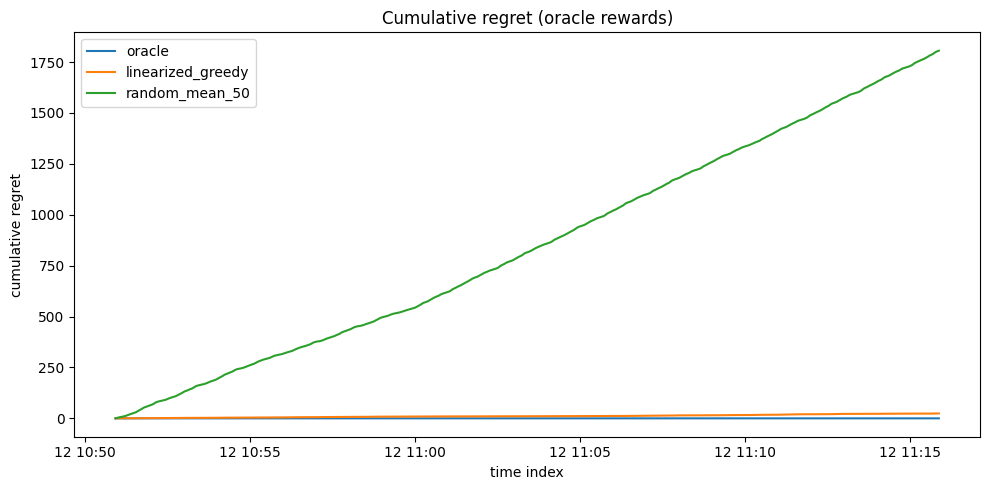

In [3]:
# ============================================================
# Deterministic baselines
# ============================================================
oracle_actions = oracle_action_indices(instance, reward_source=REWARD_MODE)
oracle_eval = evaluate_action_indices(
    instance,
    oracle_actions,
    evaluation_source=REWARD_MODE,
    realized_source=REWARD_MODE,
    ks=(1, 3),
)

linearized_greedy_actions = greedy_action_indices_from_reward_source(instance, reward_source="linearized")
linearized_greedy_eval = evaluate_action_indices(
    instance,
    linearized_greedy_actions,
    evaluation_source=REWARD_MODE,
    realized_source=REWARD_MODE,
    ks=(1, 3),
)

# ============================================================
# Random baseline averaged over several trials
# ============================================================
random_summaries = []
random_regret_traces = []

for trial in range(RANDOM_BASELINE_TRIALS):
    rand_actions = random_action_indices(instance, seed=RANDOM_BASELINE_SEED0 + trial)
    rand_eval = evaluate_action_indices(
        instance,
        rand_actions,
        evaluation_source=REWARD_MODE,
        realized_source=REWARD_MODE,
        ks=(1, 3),
    )
    random_summaries.append(rand_eval["summary"])
    random_regret_traces.append(rand_eval["regrets"])

random_df = pd.DataFrame(random_summaries)
random_summary = random_df.mean(numeric_only=True).to_dict()
random_regret_mean_trace = np.mean(np.stack(random_regret_traces), axis=0)

# ============================================================
# Collect comparison table
# ============================================================
compare = pd.DataFrame([
    {"method": "oracle", **oracle_eval["summary"]},
    {"method": "linearized_greedy", **linearized_greedy_eval["summary"]},
    {"method": f"random_uniform_mean_{RANDOM_BASELINE_TRIALS}trials", **random_summary},
])

display(compare)

# ============================================================
# Plot cumulative regret traces
# ============================================================
oracle_cum_regret = cumulative_sum(oracle_eval["regrets"])
lin_cum_regret = cumulative_sum(linearized_greedy_eval["regrets"])
rand_cum_regret = cumulative_sum(random_regret_mean_trace)

plt.figure(figsize=(10, 5))
plt.plot(instance.times, oracle_cum_regret, label="oracle")
plt.plot(instance.times, lin_cum_regret, label="linearized_greedy")
plt.plot(instance.times, rand_cum_regret, label=f"random_mean_{RANDOM_BASELINE_TRIALS}")
plt.title(f"Cumulative regret ({REWARD_MODE} rewards)")
plt.xlabel("time index")
plt.ylabel("cumulative regret")
plt.legend()
plt.tight_layout()
plt.show()

,value
num_times,7473.000000
"total_(t,a)_pairs",964017.000000
feature_dim,25.000000
mean_actions_per_t,129.000000
min_actions_per_t,129.000000
max_actions_per_t,129.000000
global_R2_all_pairs,0.967850
global_RMSE_all_pairs,0.032377
global_MAE_all_pairs,0.021245
global_corr_all_pairs,0.983846


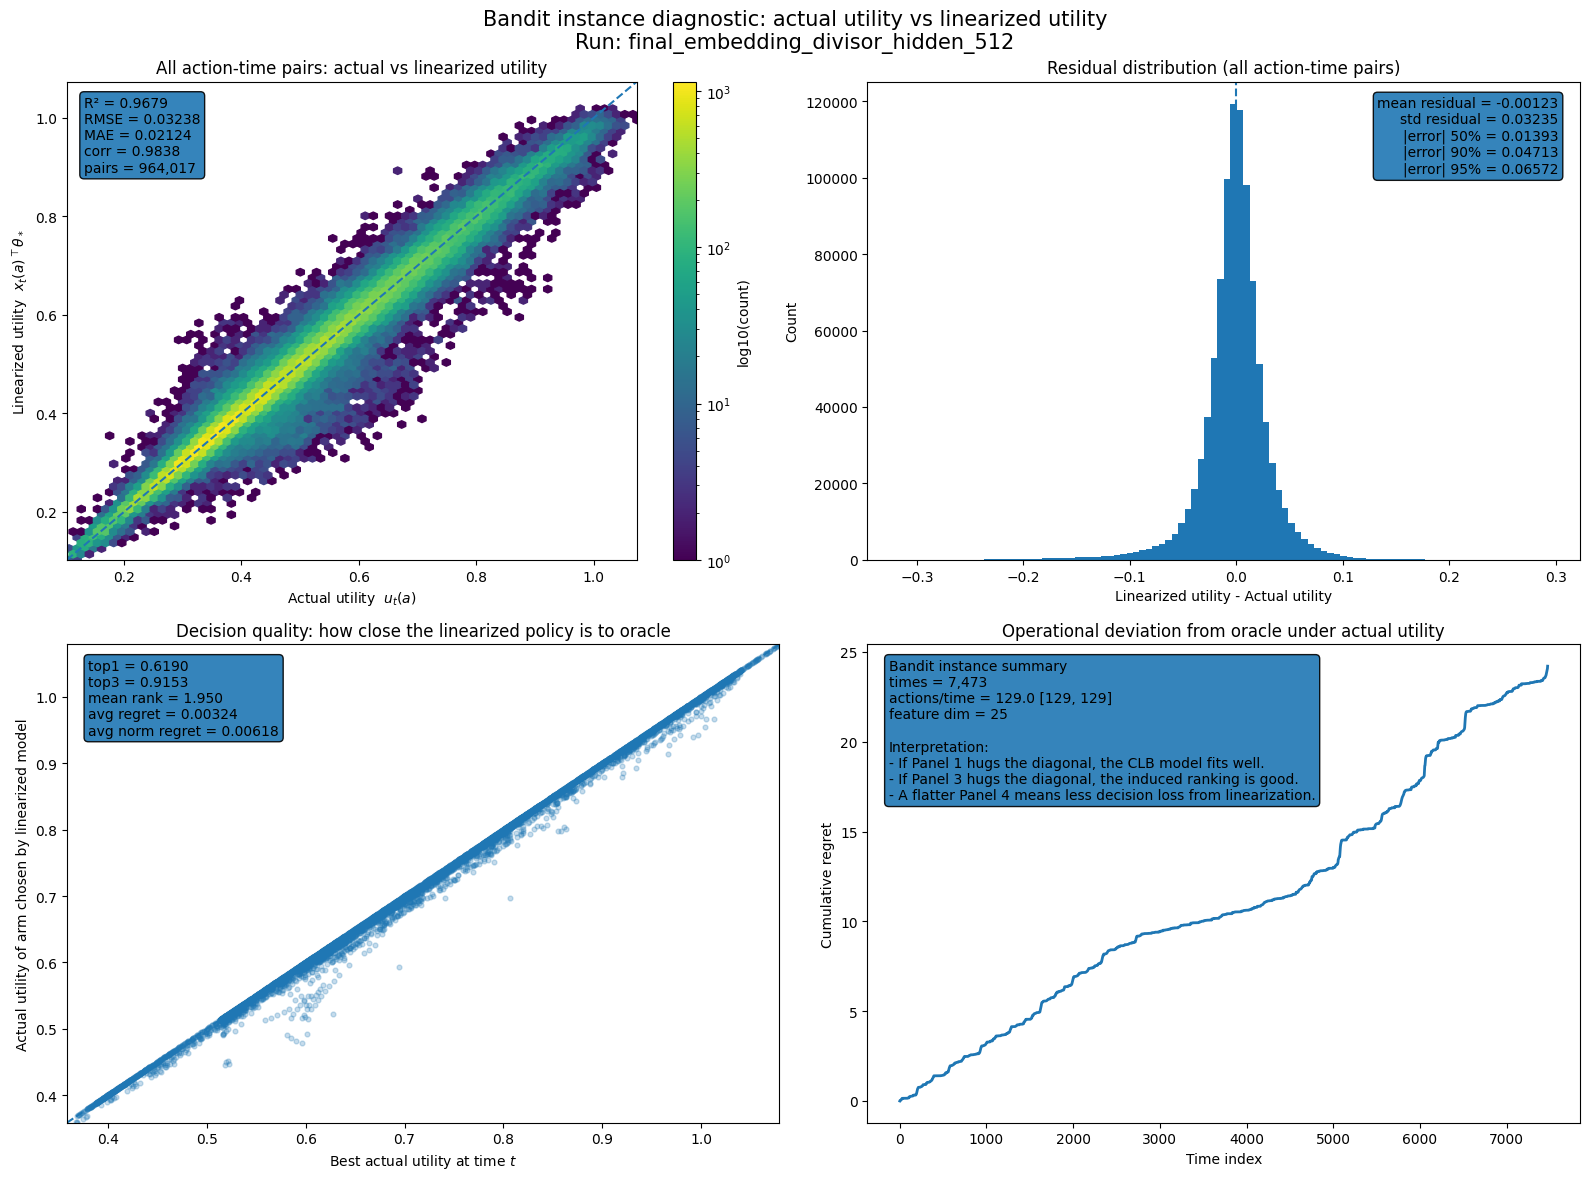

In [4]:
# ============================================================
# Plot the real utility vs linearized utility for the bandit instance
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# If needed, rebuild so we are sure the instance includes the real/oracle utility
instance = build_bandit_instance_from_run(
    RUN_DIR,
    reward_mode="oracle",          # keep the real utility available
    include_intercept=True,
    sort_rows=True,
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _get_oracle_rewards_by_t(instance):
    """
    Tries a few likely attribute names for the real/oracle utility.
    """
    # if rewards are stored in a dictionary
    if hasattr(instance, "reward_mats"):
        reward_mats = getattr(instance, "reward_mats")
        if isinstance(reward_mats, dict):
            for key in ["oracle", "actual", "real", "observed"]:
                if key in reward_mats:
                    return reward_mats[key]

    # common attribute names
    candidates = [
        "oracle_rewards_by_t",
        "actual_rewards_by_t",
        "real_rewards_by_t",
        "observed_rewards_by_t",
        "rewards_by_t",
        "utility_by_t",
        "y_by_t",
        "Y_by_t",
    ]
    for name in candidates:
        if hasattr(instance, name):
            return getattr(instance, name)

    raise AttributeError(
        "Could not find real/oracle rewards inside instance. "
        "Inspect `vars(instance).keys()` to see available fields."
    )

def _get_linearized_rewards_by_t(instance):
    """
    Linearized utility is always X_t @ theta_star.
    """
    if not hasattr(instance, "X_by_t"):
        raise AttributeError("instance has no X_by_t")
    if not hasattr(instance, "theta_star"):
        raise AttributeError("instance has no theta_star")
    return [X @ instance.theta_star for X in instance.X_by_t]

def _rank_of_choice_desc(values, chosen_idx):
    """
    Rank under descending sort: 1 = best arm.
    """
    return 1 + np.sum(values > values[chosen_idx])

# ------------------------------------------------------------
# Extract utilities
# ------------------------------------------------------------
oracle_rewards_by_t = _get_oracle_rewards_by_t(instance)
linear_rewards_by_t = _get_linearized_rewards_by_t(instance)

num_times = len(oracle_rewards_by_t)
num_actions_per_t = np.array([len(r) for r in oracle_rewards_by_t])
total_pairs = int(num_actions_per_t.sum())

# Flatten all (t,a) pairs
oracle_flat = np.concatenate(oracle_rewards_by_t)
linear_flat = np.concatenate(linear_rewards_by_t)

# Global fit metrics over all (t,a)
global_r2 = r2_score(oracle_flat, linear_flat)
global_rmse = np.sqrt(mean_squared_error(oracle_flat, linear_flat))
global_mae = np.mean(np.abs(linear_flat - oracle_flat))
global_corr = np.corrcoef(oracle_flat, linear_flat)[0, 1]

# ------------------------------------------------------------
# Per-time decision metrics
# ------------------------------------------------------------
best_oracle_util = []
chosen_by_linear_oracle_util = []
best_linear_util = []
regrets = []
norm_regrets = []
top1 = []
top3 = []
mean_ranks = []

for t in range(num_times):
    u_true = oracle_rewards_by_t[t]
    u_lin = linear_rewards_by_t[t]

    a_true = int(np.argmax(u_true))
    a_lin = int(np.argmax(u_lin))

    u_true_best = float(u_true[a_true])
    u_true_chosen = float(u_true[a_lin])
    u_lin_best = float(u_lin[a_lin])

    regret_t = u_true_best - u_true_chosen
    denom_t = max(u_true_best - float(np.min(u_true)), 1e-12)
    norm_regret_t = regret_t / denom_t

    rank_t = _rank_of_choice_desc(u_true, a_lin)

    best_oracle_util.append(u_true_best)
    chosen_by_linear_oracle_util.append(u_true_chosen)
    best_linear_util.append(u_lin_best)
    regrets.append(regret_t)
    norm_regrets.append(norm_regret_t)
    top1.append(rank_t == 1)
    top3.append(rank_t <= 3)
    mean_ranks.append(rank_t)

best_oracle_util = np.array(best_oracle_util)
chosen_by_linear_oracle_util = np.array(chosen_by_linear_oracle_util)
best_linear_util = np.array(best_linear_util)
regrets = np.array(regrets)
norm_regrets = np.array(norm_regrets)
top1 = np.array(top1, dtype=float)
top3 = np.array(top3, dtype=float)
mean_ranks = np.array(mean_ranks, dtype=float)

summary = {
    "num_times": num_times,
    "total_(t,a)_pairs": total_pairs,
    "feature_dim": int(instance.feature_dim) if hasattr(instance, "feature_dim") else int(instance.X_by_t[0].shape[1]),
    "mean_actions_per_t": float(np.mean(num_actions_per_t)),
    "min_actions_per_t": int(np.min(num_actions_per_t)),
    "max_actions_per_t": int(np.max(num_actions_per_t)),
    "global_R2_all_pairs": global_r2,
    "global_RMSE_all_pairs": global_rmse,
    "global_MAE_all_pairs": global_mae,
    "global_corr_all_pairs": global_corr,
    "top1_match_rate": float(np.mean(top1)),
    "top3_rate": float(np.mean(top3)),
    "mean_rank": float(np.mean(mean_ranks)),
    "avg_regret": float(np.mean(regrets)),
    "avg_norm_regret": float(np.mean(norm_regrets)),
}

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

# ------------------------------------------------------------
# For plotting dense scatter more cleanly, subsample if huge
# ------------------------------------------------------------
max_scatter_points = 120_000
if len(oracle_flat) > max_scatter_points:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(oracle_flat), size=max_scatter_points, replace=False)
    oracle_scatter = oracle_flat[idx]
    linear_scatter = linear_flat[idx]
else:
    oracle_scatter = oracle_flat
    linear_scatter = linear_flat

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flatten()

# --- Panel 1: actual vs linearized utility over all (t,a) ---
hb = ax1.hexbin(
    oracle_scatter,
    linear_scatter,
    gridsize=70,
    mincnt=1,
    bins="log"
)
lims = [
    min(oracle_scatter.min(), linear_scatter.min()),
    max(oracle_scatter.max(), linear_scatter.max())
]
ax1.plot(lims, lims, linestyle="--")
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel("Actual utility  $u_t(a)$")
ax1.set_ylabel("Linearized utility  $x_t(a)^\\top \\theta_*$")
ax1.set_title("All action-time pairs: actual vs linearized utility")

cb = fig.colorbar(hb, ax=ax1)
cb.set_label("log10(count)")

txt1 = (
    f"R² = {global_r2:.4f}\n"
    f"RMSE = {global_rmse:.5f}\n"
    f"MAE = {global_mae:.5f}\n"
    f"corr = {global_corr:.4f}\n"
    f"pairs = {total_pairs:,}"
)
ax1.text(
    0.03, 0.97, txt1,
    transform=ax1.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.9)
)

# --- Panel 2: residual distribution ---
residuals = linear_flat - oracle_flat
ax2.hist(residuals, bins=100)
ax2.axvline(0.0, linestyle="--")
ax2.set_xlabel("Linearized utility - Actual utility")
ax2.set_ylabel("Count")
ax2.set_title("Residual distribution (all action-time pairs)")

txt2 = (
    f"mean residual = {np.mean(residuals):.5f}\n"
    f"std residual = {np.std(residuals):.5f}\n"
    f"|error| 50% = {np.quantile(np.abs(residuals), 0.50):.5f}\n"
    f"|error| 90% = {np.quantile(np.abs(residuals), 0.90):.5f}\n"
    f"|error| 95% = {np.quantile(np.abs(residuals), 0.95):.5f}"
)
ax2.text(
    0.97, 0.97, txt2,
    transform=ax2.transAxes,
    va="top", ha="right",
    bbox=dict(boxstyle="round", alpha=0.9)
)

# --- Panel 3: decision quality under the real utility ---
# x-axis: true best utility at time t
# y-axis: actual utility of the arm selected by the linear model
ax3.scatter(best_oracle_util, chosen_by_linear_oracle_util, alpha=0.25, s=12)
lims3 = [
    min(best_oracle_util.min(), chosen_by_linear_oracle_util.min()),
    max(best_oracle_util.max(), chosen_by_linear_oracle_util.max())
]
ax3.plot(lims3, lims3, linestyle="--")
ax3.set_xlim(lims3)
ax3.set_ylim(lims3)
ax3.set_xlabel("Best actual utility at time $t$")
ax3.set_ylabel("Actual utility of arm chosen by linearized model")
ax3.set_title("Decision quality: how close the linearized policy is to oracle")

txt3 = (
    f"top1 = {np.mean(top1):.4f}\n"
    f"top3 = {np.mean(top3):.4f}\n"
    f"mean rank = {np.mean(mean_ranks):.3f}\n"
    f"avg regret = {np.mean(regrets):.5f}\n"
    f"avg norm regret = {np.mean(norm_regrets):.5f}"
)
ax3.text(
    0.03, 0.97, txt3,
    transform=ax3.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.9)
)

# --- Panel 4: cumulative regret over time ---
cum_regret = np.cumsum(regrets)
ax4.plot(np.arange(num_times), cum_regret, linewidth=2)
ax4.set_xlabel("Time index")
ax4.set_ylabel("Cumulative regret")
ax4.set_title("Operational deviation from oracle under actual utility")

txt4 = (
    f"Bandit instance summary\n"
    f"times = {num_times:,}\n"
    f"actions/time = {np.mean(num_actions_per_t):.1f} "
    f"[{np.min(num_actions_per_t)}, {np.max(num_actions_per_t)}]\n"
    f"feature dim = {summary['feature_dim']}\n\n"
    f"Interpretation:\n"
    f"- If Panel 1 hugs the diagonal, the CLB model fits well.\n"
    f"- If Panel 3 hugs the diagonal, the induced ranking is good.\n"
    f"- A flatter Panel 4 means less decision loss from linearization."
)
ax4.text(
    0.03, 0.97, txt4,
    transform=ax4.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.9)
)

run_name = RUN_DIR.name if isinstance(RUN_DIR, (str, Path)) else "selected_run"
fig.suptitle(
    f"Bandit instance diagnostic: actual utility vs linearized utility\nRun: {run_name}",
    fontsize=15
)

plt.tight_layout()
plt.show()

,value
num_times,7473.000000
feature_dim,25.000000
mean_actions_per_t,129.000000
global_R2_all_pairs,0.967850
global_RMSE_all_pairs,0.032377
global_MAE_all_pairs,0.021245
global_corr_all_pairs,0.983846
avg_best_actual_utility,0.731229
avg_chosen_actual_utility,0.727990
avg_worst_actual_utility,0.162904


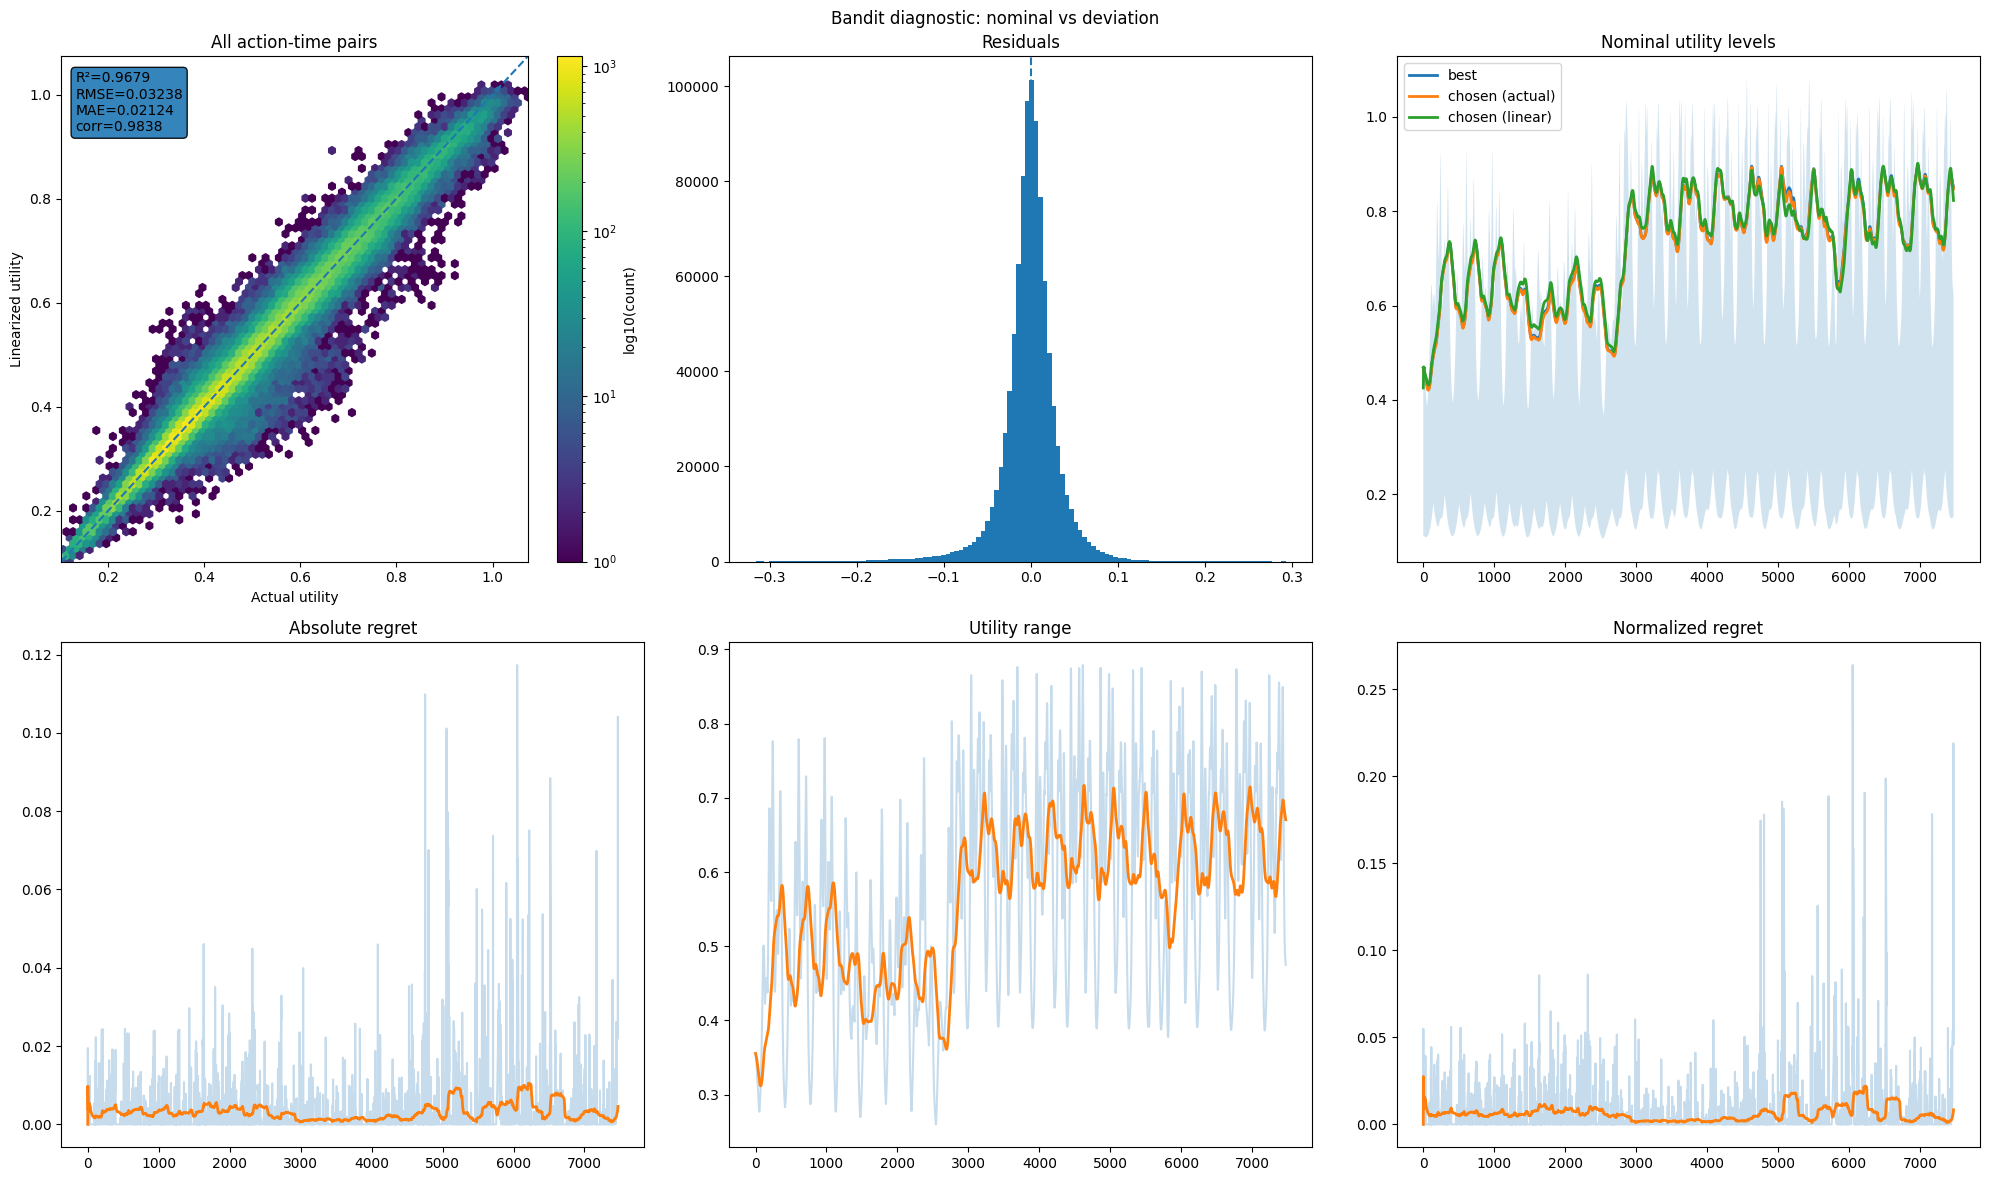

In [5]:
# ============================================================
# Presentation-quality diagnostic:
# nominal utility levels, absolute regret, utility range,
# and normalized regret are shown on separate panels.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Build / load instance if needed
# ------------------------------------------------------------
instance = build_bandit_instance_from_run(
    RUN_DIR,
    reward_mode="oracle",   # keep actual utility as the main reference
    include_intercept=True,
    sort_rows=True,
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _get_oracle_rewards_by_t(instance):
    if hasattr(instance, "oracle_rewards_by_t"):
        return instance.oracle_rewards_by_t
    if hasattr(instance, "reward_mats") and isinstance(instance.reward_mats, dict):
        for key in ["oracle", "actual", "real", "observed"]:
            if key in instance.reward_mats:
                return instance.reward_mats[key]
    if hasattr(instance, "rewards_by_t"):
        return instance.rewards_by_t
    raise AttributeError("Could not find oracle/actual rewards in instance.")

def _get_linearized_rewards_by_t(instance):
    if hasattr(instance, "linearized_rewards_by_t"):
        return instance.linearized_rewards_by_t
    if hasattr(instance, "X_by_t") and hasattr(instance, "theta_star"):
        return [X @ instance.theta_star for X in instance.X_by_t]
    raise AttributeError("Could not construct linearized rewards from instance.")

def _rolling_mean(x, w=200):
    x = np.asarray(x, dtype=float)
    return pd.Series(x).rolling(window=w, min_periods=1, center=False).mean().to_numpy()

# ------------------------------------------------------------
# Extract rewards
# ------------------------------------------------------------
oracle_rewards_by_t = _get_oracle_rewards_by_t(instance)
linear_rewards_by_t = _get_linearized_rewards_by_t(instance)

num_times = len(oracle_rewards_by_t)
time_idx = np.arange(num_times)

oracle_flat = np.concatenate(oracle_rewards_by_t)
linear_flat = np.concatenate(linear_rewards_by_t)
residuals_flat = linear_flat - oracle_flat

global_r2   = r2_score(oracle_flat, linear_flat)
global_rmse = np.sqrt(mean_squared_error(oracle_flat, linear_flat))
global_mae  = np.mean(np.abs(residuals_flat))
global_corr = np.corrcoef(oracle_flat, linear_flat)[0, 1]

# ------------------------------------------------------------
# Per-time decision quantities
# ------------------------------------------------------------
best_actual        = []
chosen_actual      = []
chosen_linearized  = []
worst_actual       = []
utility_range      = []
abs_regret         = []
norm_regret        = []
chosen_rank        = []
top1               = []
top3               = []

for t in range(num_times):
    u_true = np.asarray(oracle_rewards_by_t[t], dtype=float)
    u_lin  = np.asarray(linear_rewards_by_t[t], dtype=float)

    a_true = int(np.argmax(u_true))
    a_lin  = int(np.argmax(u_lin))

    best_u  = float(u_true[a_true])
    chosen_u = float(u_true[a_lin])      # actual utility of chosen arm
    chosen_lin_u = float(u_lin[a_lin])   # linearized utility of chosen arm
    worst_u = float(np.min(u_true))

    rng = max(best_u - worst_u, 1e-12)
    regret_t = best_u - chosen_u
    rank_t   = 1 + np.sum(u_true > u_true[a_lin])

    best_actual.append(best_u)
    chosen_actual.append(chosen_u)
    chosen_linearized.append(chosen_lin_u)
    worst_actual.append(worst_u)
    utility_range.append(rng)
    abs_regret.append(regret_t)
    norm_regret.append(regret_t / rng)
    chosen_rank.append(rank_t)
    top1.append(rank_t == 1)
    top3.append(rank_t <= 3)

best_actual        = np.asarray(best_actual)
chosen_actual      = np.asarray(chosen_actual)
chosen_linearized  = np.asarray(chosen_linearized)
worst_actual       = np.asarray(worst_actual)
utility_range      = np.asarray(utility_range)
abs_regret         = np.asarray(abs_regret)
norm_regret        = np.asarray(norm_regret)
chosen_rank        = np.asarray(chosen_rank, dtype=float)
top1               = np.asarray(top1, dtype=float)
top3               = np.asarray(top3, dtype=float)

ROLL_W = 200

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
summary = {
    "num_times": num_times,
    "feature_dim": int(instance.feature_dim)
        if hasattr(instance, "feature_dim")
        else int(instance.X_by_t[0].shape[1]),
    "mean_actions_per_t": float(np.mean([len(x) for x in oracle_rewards_by_t])),
    "global_R2_all_pairs": global_r2,
    "global_RMSE_all_pairs": global_rmse,
    "global_MAE_all_pairs": global_mae,
    "global_corr_all_pairs": global_corr,
    "avg_best_actual_utility": float(np.mean(best_actual)),
    "avg_chosen_actual_utility": float(np.mean(chosen_actual)),
    "avg_worst_actual_utility": float(np.mean(worst_actual)),
    "avg_utility_range": float(np.mean(utility_range)),
    "avg_abs_regret": float(np.mean(abs_regret)),
    "avg_norm_regret": float(np.mean(norm_regret)),
    "top1_rate": float(np.mean(top1)),
    "top3_rate": float(np.mean(top3)),
    "mean_rank": float(np.mean(chosen_rank)),
}

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

# ------------------------------------------------------------
# Scatter subsample for readability
# ------------------------------------------------------------
max_scatter_points = 120_000
if len(oracle_flat) > max_scatter_points:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(oracle_flat), size=max_scatter_points, replace=False)
    oracle_scatter = oracle_flat[idx]
    linear_scatter = linear_flat[idx]
else:
    oracle_scatter = oracle_flat
    linear_scatter = linear_flat

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# 1) Actual vs linearized
hb = ax1.hexbin(oracle_scatter, linear_scatter, gridsize=70, mincnt=1, bins="log")
lims = [
    min(oracle_scatter.min(), linear_scatter.min()),
    max(oracle_scatter.max(), linear_scatter.max()),
]
ax1.plot(lims, lims, linestyle="--")
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel("Actual utility")
ax1.set_ylabel("Linearized utility")
ax1.set_title("All action-time pairs")

cb = fig.colorbar(hb, ax=ax1)
cb.set_label("log10(count)")

ax1.text(
    0.03, 0.97,
    f"R²={global_r2:.4f}\nRMSE={global_rmse:.5f}\nMAE={global_mae:.5f}\ncorr={global_corr:.4f}",
    transform=ax1.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.9),
)

# 2) Residuals
ax2.hist(residuals_flat, bins=120)
ax2.axvline(0.0, linestyle="--")
ax2.set_title("Residuals")

# 3) Nominal utilities
ax3.fill_between(time_idx, worst_actual, best_actual, alpha=0.2)
ax3.plot(time_idx, _rolling_mean(best_actual, ROLL_W), linewidth=2, label="best")
ax3.plot(time_idx, _rolling_mean(chosen_actual, ROLL_W), linewidth=2, label="chosen (actual)")
ax3.plot(time_idx, _rolling_mean(chosen_linearized, ROLL_W), linewidth=2, label="chosen (linear)")
ax3.set_title("Nominal utility levels")
ax3.legend()

# 4) Absolute regret
ax4.plot(time_idx, abs_regret, alpha=0.25)
ax4.plot(time_idx, _rolling_mean(abs_regret, ROLL_W), linewidth=2)
ax4.set_title("Absolute regret")

# 5) Utility range
ax5.plot(time_idx, utility_range, alpha=0.25)
ax5.plot(time_idx, _rolling_mean(utility_range, ROLL_W), linewidth=2)
ax5.set_title("Utility range")

# 6) Normalized regret
ax6.plot(time_idx, norm_regret, alpha=0.25)
ax6.plot(time_idx, _rolling_mean(norm_regret, ROLL_W), linewidth=2)
ax6.set_title("Normalized regret")

fig.suptitle("Bandit diagnostic: nominal vs deviation")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter
from math import gcd
from functools import reduce

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# -----------------------------
# 1. Build action-set summaries
# -----------------------------

def stack_action_sets(instance, drop_intercept=True):
    """
    Returns A_flat[t] = vec(X_by_t[t]) after optionally dropping intercept column.
    Uses only the action-set matrices X_t, not rewards.
    """
    X_list = []
    for X in instance.X_by_t:
        X = np.asarray(X, dtype=float)

        if drop_intercept and X.shape[1] > 1:
            # If first column is an intercept, drop it.
            if np.allclose(X[:, 0], 1.0):
                X = X[:, 1:]

        X_list.append(X.reshape(-1))

    return np.vstack(X_list)


def compress_action_sets(A_flat, pca_dim=10, standardize=True, random_state=0):
    """
    Standardize flattened action sets and reduce dimensionality with PCA.
    """
    if standardize:
        scaler = StandardScaler()
        Z0 = scaler.fit_transform(A_flat)
    else:
        scaler = None
        Z0 = A_flat.copy()

    pca = PCA(n_components=pca_dim, random_state=random_state)
    Z = pca.fit_transform(Z0)

    return Z, scaler, pca


# -----------------------------
# 2. Autocorrelation diagnostics
# -----------------------------

def autocorr_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)

    if denom <= 1e-12:
        return np.full(max_lag + 1, np.nan)

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0

    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(x[:-lag], x[lag:]) / denom

    return acf


def multivariate_autocorr(Z, max_lag=200, n_components=None):
    """
    Computes average absolute autocorrelation over PCA coordinates.
    """
    if n_components is None:
        n_components = Z.shape[1]

    acfs = []
    for j in range(n_components):
        acfs.append(autocorr_1d(Z[:, j], max_lag=max_lag))

    acfs = np.vstack(acfs)
    mean_abs_acf = np.nanmean(np.abs(acfs), axis=0)

    return mean_abs_acf, acfs


def fit_beta_from_acf(acf, min_lag=1, max_lag=None, min_acf=1e-3):
    """
    Fits |acf(lag)| ≈ C beta^lag.
    Returns beta = exp(slope).
    """
    acf = np.asarray(acf, dtype=float)

    if max_lag is None:
        max_lag = len(acf) - 1

    lags = np.arange(len(acf))
    mask = (
        (lags >= min_lag)
        & (lags <= max_lag)
        & np.isfinite(acf)
        & (acf > min_acf)
        & (acf < 0.999)
    )

    if mask.sum() < 3:
        return np.nan, np.nan, None

    x = lags[mask]
    y = np.log(acf[mask])

    slope, intercept = np.polyfit(x, y, 1)
    beta = float(np.exp(slope))

    # R^2 of log-linear fit
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    return beta, r2, (x, y, y_hat)


# -----------------------------
# 3. Finite-state Markov proxy
# -----------------------------

def cluster_context_states(Z, n_states=20, random_state=0):
    """
    Clusters compressed action-set summaries into discrete proxy states.
    """
    km = KMeans(
        n_clusters=n_states,
        n_init=20,
        random_state=random_state,
    )
    labels = km.fit_predict(Z)
    return labels, km


def estimate_transition_matrix(labels, n_states, smoothing=0.0):
    """
    Estimate P_hat[i,j] = Pr(S_{t+1}=j | S_t=i).
    Optional Laplace smoothing makes the chain positive/ergodic.
    """
    counts = np.full((n_states, n_states), smoothing, dtype=float)

    for s, sp in zip(labels[:-1], labels[1:]):
        counts[s, sp] += 1.0

    row_sums = counts.sum(axis=1, keepdims=True)

    # Avoid division by zero for truly unvisited states.
    P = np.divide(
        counts,
        row_sums,
        out=np.ones_like(counts) / n_states,
        where=row_sums > 0,
    )

    return P, counts


def stationary_distribution(P):
    """
    Computes stationary distribution of finite Markov chain.
    """
    eigvals, eigvecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    pi = np.maximum(pi, 0)

    if pi.sum() <= 1e-12:
        # Fallback: solve least squares.
        n = P.shape[0]
        A = np.vstack([P.T - np.eye(n), np.ones(n)])
        b = np.concatenate([np.zeros(n), [1.0]])
        pi = np.linalg.lstsq(A, b, rcond=None)[0]
        pi = np.maximum(pi, 0)

    pi = pi / pi.sum()
    return pi


def graph_reachable(adj, start):
    n = adj.shape[0]
    seen = np.zeros(n, dtype=bool)
    stack = [start]
    seen[start] = True

    while stack:
        u = stack.pop()
        for v in np.where(adj[u])[0]:
            if not seen[v]:
                seen[v] = True
                stack.append(v)

    return seen


def is_irreducible(P, tol=1e-12):
    """
    Checks strong connectivity of transition graph.
    """
    adj = P > tol
    n = P.shape[0]

    for s in range(n):
        if not graph_reachable(adj, s).all():
            return False

    return True


def has_self_loop(P, tol=1e-12):
    return bool(np.any(np.diag(P) > tol))


def slem(P):
    """
    Second largest eigenvalue modulus.
    For a finite ergodic chain, this is a useful mixing-rate proxy.
    """
    vals = np.linalg.eigvals(P)
    mods = np.sort(np.abs(vals))[::-1]

    if len(mods) < 2:
        return 0.0

    return float(mods[1])


def tv_distance(p, q):
    return 0.5 * np.sum(np.abs(p - q))


def max_tv_to_stationary_by_lag(P, max_lag=100):
    """
    Computes max_i TV(e_i P^lag, pi), lag=0,...,max_lag.
    """
    n = P.shape[0]
    pi = stationary_distribution(P)

    P_power = np.eye(n)
    tvs = []

    for lag in range(max_lag + 1):
        d = max(tv_distance(P_power[i], pi) for i in range(n))
        tvs.append(d)
        P_power = P_power @ P

    return np.array(tvs), pi


def dobrushin_coefficient(P):
    """
    Dobrushin contraction coefficient:
        delta(P) = 0.5 max_{i,j} ||P_i - P_j||_1

    If delta(P) < 1, then TV(mu P, nu P) <= delta(P) TV(mu, nu).
    """
    n = P.shape[0]
    max_l1 = 0.0

    for i in range(n):
        for j in range(n):
            max_l1 = max(max_l1, np.sum(np.abs(P[i] - P[j])))

    return 0.5 * max_l1


def beta_from_dobrushin_powers(P, max_power=50):
    """
    Uses powers P^m and returns min_m delta(P^m)^(1/m).
    This is a conservative empirical contraction-rate proxy.
    """
    P_power = np.eye(P.shape[0])

    rows = []
    best_beta = np.inf
    best_m = None

    for m in range(1, max_power + 1):
        P_power = P_power @ P
        delta_m = dobrushin_coefficient(P_power)
        beta_m = delta_m ** (1.0 / m)

        rows.append({
            "m": m,
            "dobrushin_delta_Pm": delta_m,
            "beta_from_delta_Pm": beta_m,
        })

        if beta_m < best_beta:
            best_beta = beta_m
            best_m = m

    return float(best_beta), int(best_m), pd.DataFrame(rows)


def fit_beta_from_tv_curve(tvs, min_lag=1, max_lag=None, min_tv=1e-6):
    """
    Fits max_i TV(e_i P^lag, pi) ≈ C beta^lag.
    """
    tvs = np.asarray(tvs, dtype=float)

    if max_lag is None:
        max_lag = len(tvs) - 1

    lags = np.arange(len(tvs))
    mask = (
        (lags >= min_lag)
        & (lags <= max_lag)
        & np.isfinite(tvs)
        & (tvs > min_tv)
        & (tvs < 0.999999)
    )

    if mask.sum() < 3:
        return np.nan, np.nan, np.nan, None

    x = lags[mask]
    y = np.log(tvs[mask])

    slope, intercept = np.polyfit(x, y, 1)
    beta = float(np.exp(slope))
    Cmix = float(np.exp(intercept))

    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    return beta, Cmix, r2, (x, y, y_hat)


# -----------------------------
# 4. First-order Markov check
# -----------------------------

def conditional_entropy_next_state(labels, n_states, order=1, smoothing=1e-3):
    """
    Estimates H(S_{t+1} | S_t) or H(S_{t+1} | S_{t-1}, S_t).
    Lower entropy means more predictable.

    order=1: condition on S_t.
    order=2: condition on (S_{t-1}, S_t).
    """
    labels = np.asarray(labels, dtype=int)

    contexts = defaultdict(lambda: np.full(n_states, smoothing, dtype=float))

    if order == 1:
        for t in range(len(labels) - 1):
            key = (labels[t],)
            nxt = labels[t + 1]
            contexts[key][nxt] += 1.0

    elif order == 2:
        for t in range(1, len(labels) - 1):
            key = (labels[t - 1], labels[t])
            nxt = labels[t + 1]
            contexts[key][nxt] += 1.0

    else:
        raise ValueError("Only order=1 and order=2 are implemented.")

    total_context_count = 0.0
    weighted_entropy = 0.0

    for counts in contexts.values():
        total = counts.sum()
        probs = counts / total
        H = -np.sum(probs * np.log(probs + 1e-15))
        weighted_entropy += total * H
        total_context_count += total

    return weighted_entropy / total_context_count


# -----------------------------
# 5. Main wrapper
# -----------------------------

def analyze_action_set_mixing(
    instance,
    pca_dim=10,
    cluster_sizes=(10, 20, 30),
    max_acf_lag=300,
    max_tv_lag=100,
    smoothing=1e-3,
    random_state=0,
    drop_intercept=True,
    plot=True,
):
    """
    Main diagnostic routine.

    Returns:
        report_df: summary over cluster sizes
        artifacts: dict with PCA features, labels, transition matrices, curves
    """
    A_flat = stack_action_sets(instance, drop_intercept=drop_intercept)
    Z, scaler, pca = compress_action_sets(
        A_flat,
        pca_dim=pca_dim,
        standardize=True,
        random_state=random_state,
    )

    acf, component_acfs = multivariate_autocorr(
        Z,
        max_lag=max_acf_lag,
        n_components=min(pca_dim, Z.shape[1]),
    )

    beta_acf, acf_fit_r2, acf_fit = fit_beta_from_acf(
        acf,
        min_lag=1,
        max_lag=max_acf_lag,
        min_acf=1e-3,
    )

    rows = []
    artifacts = {
        "A_flat": A_flat,
        "Z": Z,
        "scaler": scaler,
        "pca": pca,
        "acf": acf,
        "component_acfs": component_acfs,
        "acf_beta": beta_acf,
        "acf_fit_r2": acf_fit_r2,
        "acf_fit": acf_fit,
        "by_cluster_size": {},
    }

    for K in cluster_sizes:
        labels, km = cluster_context_states(Z, n_states=K, random_state=random_state)

        P_raw, counts_raw = estimate_transition_matrix(labels, K, smoothing=0.0)
        P_smooth, counts_smooth = estimate_transition_matrix(labels, K, smoothing=smoothing)

        raw_irred = is_irreducible(P_raw)
        raw_self_loop = has_self_loop(P_raw)

        smooth_irred = is_irreducible(P_smooth)
        smooth_self_loop = has_self_loop(P_smooth)

        pi = stationary_distribution(P_smooth)
        beta_slem = slem(P_smooth)

        tvs, _ = max_tv_to_stationary_by_lag(P_smooth, max_lag=max_tv_lag)
        beta_tv_fit, Cmix_fit, tv_fit_r2, tv_fit = fit_beta_from_tv_curve(
            tvs,
            min_lag=1,
            max_lag=max_tv_lag,
            min_tv=1e-6,
        )

        beta_dobr, best_m, dobr_df = beta_from_dobrushin_powers(
            P_smooth,
            max_power=max_tv_lag,
        )

        H1 = conditional_entropy_next_state(labels, K, order=1, smoothing=smoothing)
        H2 = conditional_entropy_next_state(labels, K, order=2, smoothing=smoothing)

        # If H2 is much lower than H1, second-order history helps a lot,
        # which weakens a first-order Markov approximation.
        entropy_improvement = H1 - H2
        rel_entropy_improvement = entropy_improvement / max(H1, 1e-12)

        visited = len(np.unique(labels))
        min_pi = pi.min()
        max_pi = pi.max()

        # Conservative empirical beta upper proxy across the finite-chain diagnostics.
        # SLEM is a rate proxy; TV fit is empirical decay; Dobrushin powers are contraction upper proxies.
        beta_candidates = [
            x for x in [beta_slem, beta_tv_fit, beta_dobr, beta_acf]
            if np.isfinite(x)
        ]
        beta_conservative = min(0.999, max(beta_candidates)) if beta_candidates else np.nan

        rows.append({
            "K_states": K,
            "visited_states": visited,
            "raw_irreducible": raw_irred,
            "raw_has_self_loop": raw_self_loop,
            "smoothed_irreducible": smooth_irred,
            "smoothed_has_self_loop": smooth_self_loop,
            "stationary_min_pi": min_pi,
            "stationary_max_pi": max_pi,
            "beta_slem": beta_slem,
            "beta_tv_fit": beta_tv_fit,
            "Cmix_tv_fit": Cmix_fit,
            "tv_fit_r2": tv_fit_r2,
            "beta_dobrushin_power": beta_dobr,
            "best_dobrushin_power_m": best_m,
            "beta_acf": beta_acf,
            "acf_fit_r2": acf_fit_r2,
            "H_next_given_current": H1,
            "H_next_given_prev_current": H2,
            "relative_second_order_entropy_gain": rel_entropy_improvement,
            "beta_conservative_proxy": beta_conservative,
        })

        artifacts["by_cluster_size"][K] = {
            "labels": labels,
            "kmeans": km,
            "P_raw": P_raw,
            "P_smooth": P_smooth,
            "counts_raw": counts_raw,
            "counts_smooth": counts_smooth,
            "pi": pi,
            "tvs": tvs,
            "tv_fit": tv_fit,
            "dobrushin_df": dobr_df,
        }

    report_df = pd.DataFrame(rows)

    if plot:
        fig = plt.figure(figsize=(8, 4))
        plt.plot(np.arange(len(acf)), acf)
        plt.yscale("log")
        plt.xlabel("lag")
        plt.ylabel("mean abs autocorrelation of PCA context coordinates")
        plt.title(f"Action-set autocorrelation decay; beta_acf ≈ {beta_acf:.4f}")
        plt.grid(True, alpha=0.3)
        plt.show()

        for K in cluster_sizes:
            tvs = artifacts["by_cluster_size"][K]["tvs"]

            plt.figure(figsize=(8, 4))
            plt.plot(np.arange(len(tvs)), tvs)
            plt.yscale("log")
            plt.xlabel("lag")
            plt.ylabel(r"max_i TV(e_i P^lag, pi)")
            plt.title(f"Empirical TV mixing curve, K={K}")
            plt.grid(True, alpha=0.3)
            plt.show()

    return report_df, artifacts

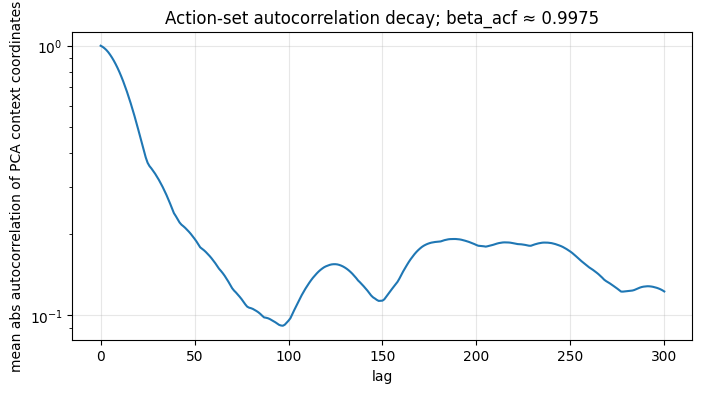

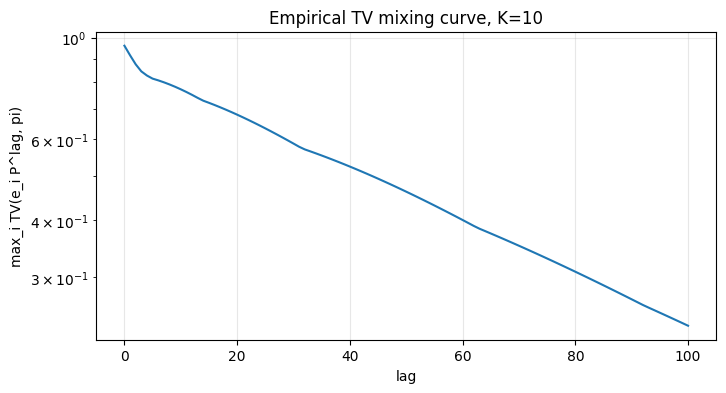

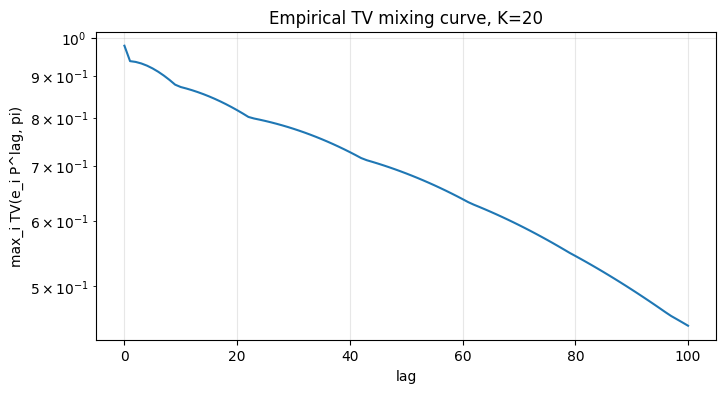

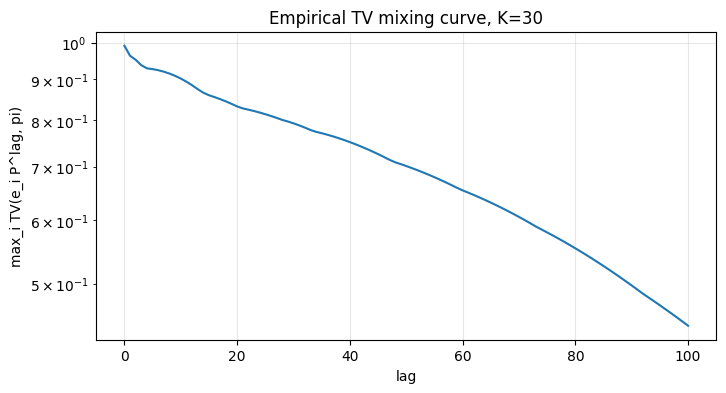

,K_states,visited_states,raw_irreducible,raw_has_self_loop,smoothed_irreducible,smoothed_has_self_loop,stationary_min_pi,stationary_max_pi,beta_slem,beta_tv_fit,Cmix_tv_fit,tv_fit_r2,beta_dobrushin_power,best_dobrushin_power_m,beta_acf,acf_fit_r2,H_next_given_current,H_next_given_prev_current,relative_second_order_entropy_gain,beta_conservative_proxy
0,10,10,True,True,True,True,0.038545,0.226042,0.982778,0.986901,0.883450,0.999567,0.990089,100,0.997488,0.199798,0.182923,0.165980,0.092623,0.997488
1,20,20,True,True,True,True,0.021682,0.100907,0.985869,0.992899,0.957697,0.992019,0.995974,100,0.997488,0.199798,0.322859,0.285635,0.115297,0.997488
2,30,30,True,True,True,True,0.008568,0.079090,0.985238,0.992730,0.985056,0.985699,0.995810,100,0.997488,0.199798,0.368363,0.326733,0.113013,0.997488



=== Conservative empirical mixing proxy ===
T = 7473
beta_hat = 0.997488
c_tau=0.25 -> tau=888
c_tau=0.5  -> tau=1776
c_tau=1.0  -> tau=3551

=== Recommended values to inspect ===


,K_states,raw_irreducible,raw_has_self_loop,beta_slem,beta_tv_fit,beta_dobrushin_power,beta_acf,relative_second_order_entropy_gain,beta_conservative_proxy
0,10,True,True,0.982778,0.986901,0.990089,0.997488,0.092623,0.997488
1,20,True,True,0.985869,0.992899,0.995974,0.997488,0.115297,0.997488
2,30,True,True,0.985238,0.992730,0.995810,0.997488,0.113013,0.997488


In [7]:
report_df, mix_artifacts = analyze_action_set_mixing(
    instance,
    pca_dim=10,
    cluster_sizes=(10, 20, 30),
    max_acf_lag=300,
    max_tv_lag=100,
    smoothing=1e-3,
    random_state=0,
    drop_intercept=True,
    plot=True,
)

display(report_df)

# Conservative empirical beta proxy across all cluster sizes.
beta_hat = report_df["beta_conservative_proxy"].max()
T = len(instance.X_by_t)

print("\n=== Conservative empirical mixing proxy ===")
print(f"T = {T}")
print(f"beta_hat = {beta_hat:.6f}")

for c_tau in [0.25, 0.5, 1.0]:
    tau = int(np.ceil(c_tau * np.log(T) / max(1.0 - beta_hat, 1e-12)))
    print(f"c_tau={c_tau:<4} -> tau={tau}")

print("\n=== Recommended values to inspect ===")
cols = [
    "K_states",
    "raw_irreducible",
    "raw_has_self_loop",
    "beta_slem",
    "beta_tv_fit",
    "beta_dobrushin_power",
    "beta_acf",
    "relative_second_order_entropy_gain",
    "beta_conservative_proxy",
]
display(report_df[cols])

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tqdm.auto import tqdm


# ============================================================
# Build matrices from the BanditInstance
# ============================================================

def get_flat_action_set_matrix(instance, drop_intercept=True, standardize=True, dtype=np.float32):
    """
    Row t is vec(X_t), where X_t is the whole action set at time t.

    X_t shape usually: (129, 25)
    If first column is intercept, optionally drop it.
    """
    rows = []

    for X in instance.X_by_t:
        X = np.asarray(X, dtype=float)

        if drop_intercept and X.shape[1] > 1 and np.allclose(X[:, 0], 1.0):
            X = X[:, 1:]

        rows.append(X.reshape(-1))

    F = np.vstack(rows).astype(dtype)

    scaler = None
    if standardize:
        scaler = StandardScaler()
        F = scaler.fit_transform(F).astype(dtype)

    return F, scaler


def get_reward_matrix(instance, source="linearized", standardize=True, dtype=np.float32):
    """
    Row t is the full reward/action-quality landscape at time t.
    """
    if source == "linearized":
        R = np.vstack([np.asarray(r, dtype=float) for r in instance.linearized_rewards_by_t])
    elif source == "oracle":
        R = np.vstack([np.asarray(r, dtype=float) for r in instance.oracle_rewards_by_t])
    elif source == "active":
        R = np.vstack([np.asarray(r, dtype=float) for r in instance.rewards_by_t])
    else:
        raise ValueError("source must be 'linearized', 'oracle', or 'active'.")

    R = R.astype(dtype)

    scaler = None
    if standardize:
        scaler = StandardScaler()
        R = scaler.fit_transform(R).astype(dtype)

    return R, scaler


def topk_indices_from_rewards(instance, k=3, source="linearized"):
    if source == "linearized":
        rewards = instance.linearized_rewards_by_t
    elif source == "oracle":
        rewards = instance.oracle_rewards_by_t
    elif source == "active":
        rewards = instance.rewards_by_t
    else:
        raise ValueError("source must be 'linearized', 'oracle', or 'active'.")

    topk = []
    top1 = []

    for r in rewards:
        r = np.asarray(r)
        idx = np.argsort(r)[::-1][:k]
        topk.append(tuple(idx.tolist()))
        top1.append(int(idx[0]))

    return np.asarray(top1), topk


# ============================================================
# Pair sampling and metrics
# ============================================================

def sample_global_pairs(n, max_pairs=20_000, rng=None):
    rng = np.random.default_rng(rng)
    i = rng.integers(0, n, size=max_pairs)
    j = rng.integers(0, n, size=max_pairs)

    bad = i == j
    while bad.any():
        j[bad] = rng.integers(0, n, size=bad.sum())
        bad = i == j

    return i, j


def sample_within_pairs(labels, max_pairs=20_000, rng=None):
    """
    Samples pairs from the same cluster, weighted by number of possible pairs.
    """
    rng = np.random.default_rng(rng)
    labels = np.asarray(labels)
    unique = np.unique(labels)

    idx_by_c = {c: np.where(labels == c)[0] for c in unique}
    valid_clusters = [c for c in unique if len(idx_by_c[c]) >= 2]

    if not valid_clusters:
        return np.array([], dtype=int), np.array([], dtype=int)

    weights = np.array([
        len(idx_by_c[c]) * (len(idx_by_c[c]) - 1)
        for c in valid_clusters
    ], dtype=float)
    weights = weights / weights.sum()

    chosen_clusters = rng.choice(valid_clusters, size=max_pairs, p=weights)

    i = np.empty(max_pairs, dtype=int)
    j = np.empty(max_pairs, dtype=int)

    for m, c in enumerate(chosen_clusters):
        idx = idx_by_c[c]
        a, b = rng.choice(idx, size=2, replace=False)
        i[m] = a
        j[m] = b

    return i, j


def sample_between_pairs(labels, max_pairs=20_000, rng=None):
    """
    Samples pairs from different clusters.
    """
    rng = np.random.default_rng(rng)
    labels = np.asarray(labels)
    n = len(labels)

    i = rng.integers(0, n, size=max_pairs)
    j = rng.integers(0, n, size=max_pairs)

    bad = labels[i] == labels[j]
    tries = 0

    while bad.any() and tries < 20:
        j[bad] = rng.integers(0, n, size=bad.sum())
        bad = labels[i] == labels[j]
        tries += 1

    keep = labels[i] != labels[j]
    return i[keep], j[keep]


def pair_metrics(M, i, j, eps=1e-12):
    """
    Computes average Euclidean distance and cosine similarity
    over sampled pairs.
    """
    if len(i) == 0:
        return {
            "dist_mean": np.nan,
            "dist_median": np.nan,
            "cos_mean": np.nan,
            "cos_median": np.nan,
        }

    A = M[i]
    B = M[j]

    diff = A - B
    dists = np.sqrt(np.sum(diff * diff, axis=1))

    An = np.sqrt(np.sum(A * A, axis=1))
    Bn = np.sqrt(np.sum(B * B, axis=1))
    cos = np.sum(A * B, axis=1) / np.maximum(An * Bn, eps)

    return {
        "dist_mean": float(np.mean(dists)),
        "dist_median": float(np.median(dists)),
        "cos_mean": float(np.mean(cos)),
        "cos_median": float(np.median(cos)),
    }


def explained_variance_by_labels(M, labels):
    """
    Computes 1 - within_cluster_MSE / global_MSE.

    Higher means clusters explain more of the variation in M.
    """
    labels = np.asarray(labels)
    global_center = M.mean(axis=0, keepdims=True)
    total_mse = float(np.mean(np.sum((M - global_center) ** 2, axis=1)))

    within_ss = 0.0
    n = M.shape[0]

    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        Mc = M[idx]
        center = Mc.mean(axis=0, keepdims=True)
        within_ss += float(np.sum(np.sum((Mc - center) ** 2, axis=1)))

    within_mse = within_ss / n

    if total_mse <= 1e-12:
        return np.nan, within_mse, total_mse

    return 1.0 - within_mse / total_mse, within_mse, total_mse


def top_action_stability(labels, top1, topk_sets, k=3, max_pairs=20_000, rng=None):
    """
    Measures decision-level coherence inside states.

    top1_majority:
        Weighted average, over clusters, of fraction occupied by the most common top-1 action.

    within_top1_same:
        Probability sampled same-state pair has identical top-1 action.

    global_top1_same:
        Probability sampled arbitrary pair has identical top-1 action.

    within_topk_jaccard:
        Mean Jaccard similarity of top-k action sets inside same state.

    global_topk_jaccard:
        Same globally.
    """
    rng = np.random.default_rng(rng)
    labels = np.asarray(labels)
    top1 = np.asarray(top1)
    n = len(labels)

    # Majority top-1 fraction per cluster
    weighted_majority = 0.0
    weighted_entropy = 0.0

    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        vals, counts = np.unique(top1[idx], return_counts=True)
        probs = counts / counts.sum()

        weighted_majority += len(idx) / n * probs.max()
        weighted_entropy += len(idx) / n * (-np.sum(probs * np.log(probs + 1e-15)))

    wi, wj = sample_within_pairs(labels, max_pairs=max_pairs, rng=rng)
    gi, gj = sample_global_pairs(n, max_pairs=max_pairs, rng=rng)

    within_top1_same = float(np.mean(top1[wi] == top1[wj])) if len(wi) else np.nan
    global_top1_same = float(np.mean(top1[gi] == top1[gj])) if len(gi) else np.nan

    def mean_jaccard(i, j):
        vals = []
        for a, b in zip(i, j):
            A = set(topk_sets[a])
            B = set(topk_sets[b])
            vals.append(len(A & B) / len(A | B))
        return float(np.mean(vals)) if vals else np.nan

    within_topk_jaccard = mean_jaccard(wi, wj)
    global_topk_jaccard = mean_jaccard(gi, gj)

    return {
        "top1_cluster_majority": float(weighted_majority),
        "top1_cluster_entropy": float(weighted_entropy),
        "within_top1_same": within_top1_same,
        "global_top1_same": global_top1_same,
        "within_top1_lift_over_global": within_top1_same / max(global_top1_same, 1e-12),
        "within_topk_jaccard": within_topk_jaccard,
        "global_topk_jaccard": global_topk_jaccard,
        "within_topk_jaccard_lift": within_topk_jaccard / max(global_topk_jaccard, 1e-12),
    }


# ============================================================
# Main sweep over K
# ============================================================

def sweep_state_coherence(
    instance,
    K_values=(5, 10, 20, 30, 40, 50, 60, 80, 100),
    pca_dim=10,
    reward_source="linearized",
    max_pairs=20_000,
    random_state=0,
    drop_intercept=True,
):
    """
    For each K:
      1. Cluster action sets using PCA(vec(X_t)).
      2. Measure within-state similarity vs global similarity.
      3. Measure between-state distinction vs global distinction.
      4. Measure reward-landscape coherence.
      5. Measure top-action/top-k stability.

    Returns:
      report_df, artifacts
    """
    rng = np.random.default_rng(random_state)

    # Full flattened action-set embeddings
    F, F_scaler = get_flat_action_set_matrix(
        instance,
        drop_intercept=drop_intercept,
        standardize=True,
        dtype=np.float32,
    )

    # Reward landscape matrix
    R, R_scaler = get_reward_matrix(
        instance,
        source=reward_source,
        standardize=True,
        dtype=np.float32,
    )

    top1, topk_sets = topk_indices_from_rewards(
        instance,
        k=3,
        source=reward_source,
    )

    # PCA only for clustering
    pca = PCA(n_components=pca_dim, random_state=random_state)
    Z = pca.fit_transform(F).astype(np.float32)

    n = F.shape[0]

    # Global pair metrics are K-independent
    gi, gj = sample_global_pairs(n, max_pairs=max_pairs, rng=rng)
    F_global = pair_metrics(F, gi, gj)
    R_global = pair_metrics(R, gi, gj)

    rows = []
    artifacts = {
        "F": F,
        "R": R,
        "Z": Z,
        "pca": pca,
        "F_scaler": F_scaler,
        "R_scaler": R_scaler,
        "top1": top1,
        "topk_sets": topk_sets,
        "global_pairs": (gi, gj),
        "F_global": F_global,
        "R_global": R_global,
        "labels_by_K": {},
    }

    for K in tqdm(K_values, desc="Sweeping K"):
        km = KMeans(
            n_clusters=K,
            n_init=20,
            random_state=random_state,
        )
        labels = km.fit_predict(Z)
        artifacts["labels_by_K"][K] = labels

        sizes = np.bincount(labels, minlength=K)

        wi, wj = sample_within_pairs(labels, max_pairs=max_pairs, rng=rng)
        bi, bj = sample_between_pairs(labels, max_pairs=max_pairs, rng=rng)

        F_within = pair_metrics(F, wi, wj)
        F_between = pair_metrics(F, bi, bj)

        R_within = pair_metrics(R, wi, wj)
        R_between = pair_metrics(R, bi, bj)

        F_expl, F_within_mse, F_total_mse = explained_variance_by_labels(F, labels)
        R_expl, R_within_mse, R_total_mse = explained_variance_by_labels(R, labels)

        top_metrics = top_action_stability(
            labels,
            top1,
            topk_sets,
            k=3,
            max_pairs=max_pairs,
            rng=rng,
        )

        row = {
            "K": K,
            "min_cluster_size": int(sizes.min()),
            "median_cluster_size": float(np.median(sizes)),
            "max_cluster_size": int(sizes.max()),

            # Action-set embedding variation
            "X_global_dist": F_global["dist_mean"],
            "X_within_dist": F_within["dist_mean"],
            "X_between_dist": F_between["dist_mean"],
            "X_within_dist_over_global": F_within["dist_mean"] / F_global["dist_mean"],
            "X_between_dist_over_global": F_between["dist_mean"] / F_global["dist_mean"],
            "X_between_over_within_dist": F_between["dist_mean"] / max(F_within["dist_mean"], 1e-12),

            "X_global_cos": F_global["cos_mean"],
            "X_within_cos": F_within["cos_mean"],
            "X_between_cos": F_between["cos_mean"],
            "X_within_cos_minus_global": F_within["cos_mean"] - F_global["cos_mean"],
            "X_global_cos_minus_between": F_global["cos_mean"] - F_between["cos_mean"],

            "X_explained_variance_by_state": F_expl,
            "X_within_mse": F_within_mse,
            "X_total_mse": F_total_mse,

            # Reward/action-quality landscape variation
            "R_global_dist": R_global["dist_mean"],
            "R_within_dist": R_within["dist_mean"],
            "R_between_dist": R_between["dist_mean"],
            "R_within_dist_over_global": R_within["dist_mean"] / R_global["dist_mean"],
            "R_between_dist_over_global": R_between["dist_mean"] / R_global["dist_mean"],
            "R_between_over_within_dist": R_between["dist_mean"] / max(R_within["dist_mean"], 1e-12),

            "R_global_cos": R_global["cos_mean"],
            "R_within_cos": R_within["cos_mean"],
            "R_between_cos": R_between["cos_mean"],
            "R_within_cos_minus_global": R_within["cos_mean"] - R_global["cos_mean"],
            "R_global_cos_minus_between": R_global["cos_mean"] - R_between["cos_mean"],

            "R_explained_variance_by_state": R_expl,
            "R_within_mse": R_within_mse,
            "R_total_mse": R_total_mse,
        }

        row.update(top_metrics)
        rows.append(row)

    report_df = pd.DataFrame(rows)

    return report_df, artifacts


# ============================================================
# Run
# ============================================================

K_values = [5, 10] + list(range(20, 101, 10))

coherence_df, coherence_artifacts = sweep_state_coherence(
    instance,
    K_values=K_values,
    pca_dim=10,
    reward_source="linearized",
    max_pairs=20_000,
    random_state=0,
    drop_intercept=True,
)

display(coherence_df)

Sweeping K:   0%|          | 0/11 [00:00<?, ?it/s]

,K,min_cluster_size,median_cluster_size,max_cluster_size,X_global_dist,X_within_dist,X_between_dist,X_within_dist_over_global,X_between_dist_over_global,X_between_over_within_dist,...,R_within_mse,R_total_mse,top1_cluster_majority,top1_cluster_entropy,within_top1_same,global_top1_same,within_top1_lift_over_global,within_topk_jaccard,global_topk_jaccard,within_topk_jaccard_lift
0,5,922,1318.0,2397,74.634201,47.217773,82.422806,0.632656,1.104357,1.745589,...,46.068318,129.0,0.430349,1.735334,0.25705,0.08370,3.071087,0.258125,0.091785,2.812279
1,10,288,665.5,1690,74.634201,34.690567,80.593109,0.464808,1.079842,2.323200,...,26.606397,129.0,0.579152,1.296373,0.40365,0.08175,4.937615,0.371510,0.091700,4.051363
2,20,162,366.0,755,74.634201,24.937700,77.579010,0.334132,1.039457,3.110913,...,10.187079,129.0,0.648602,0.998020,0.52095,0.08020,6.495636,0.469270,0.088495,5.302785
3,30,64,230.0,592,74.634201,22.011965,76.883125,0.294931,1.030133,3.492788,...,6.884276,129.0,0.683394,0.887655,0.55620,0.08180,6.799511,0.490740,0.092435,5.309028
4,40,59,155.5,484,74.634201,20.102459,76.494499,0.269346,1.024926,3.805231,...,5.371116,129.0,0.706677,0.800417,0.59030,0.08155,7.238504,0.514865,0.090060,5.716911
5,50,56,139.0,353,74.634201,18.774130,75.656479,0.251549,1.013697,4.029826,...,4.285797,129.0,0.732504,0.751816,0.62800,0.08235,7.625987,0.544455,0.092860,5.863181
6,60,34,111.0,342,74.634201,18.142841,75.882965,0.243090,1.016732,4.182529,...,3.679275,129.0,0.744948,0.718820,0.62695,0.08445,7.423919,0.561265,0.092115,6.093090
7,70,32,91.0,294,74.634201,17.422882,75.666740,0.233444,1.013835,4.342952,...,3.255778,129.0,0.745751,0.683004,0.64460,0.08175,7.885015,0.578490,0.091585,6.316427
8,80,33,88.5,285,74.634201,16.784597,75.371353,0.224891,1.009877,4.490507,...,3.018740,129.0,0.753780,0.677657,0.63635,0.08335,7.634673,0.573040,0.093125,6.153450
9,90,12,73.5,284,74.634201,16.312687,75.542076,0.218569,1.012164,4.630879,...,2.733974,129.0,0.761542,0.646377,0.66815,0.08340,8.011391,0.593350,0.094445,6.282492


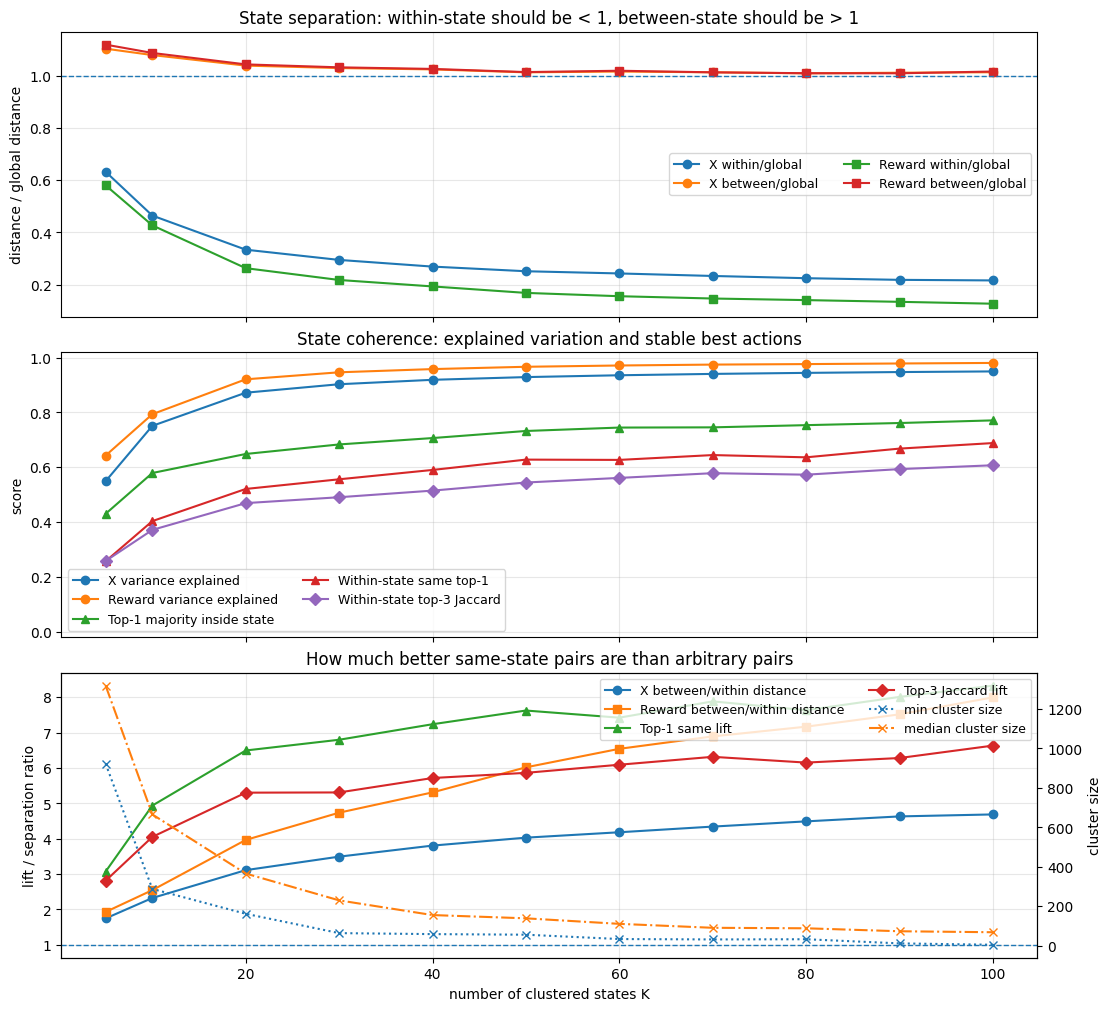

,K,min_cluster_size,median_cluster_size,X_within_dist_over_global,X_between_dist_over_global,X_between_over_within_dist,X_explained_variance_by_state,R_within_dist_over_global,R_between_dist_over_global,R_between_over_within_dist,R_explained_variance_by_state,top1_cluster_majority,within_top1_same,within_top1_lift_over_global,within_topk_jaccard,within_topk_jaccard_lift
0,5,922,1318.000000,0.632700,1.104400,1.745600,0.549300,0.580700,1.119900,1.928600,0.642900,0.430300,0.257000,3.071100,0.258100,2.812300
1,10,288,665.500000,0.464800,1.079800,2.323200,0.751200,0.427300,1.087900,2.545800,0.793700,0.579200,0.403600,4.937600,0.371500,4.051400
2,20,162,366.000000,0.334100,1.039500,3.110900,0.872200,0.263300,1.044100,3.965400,0.921000,0.648600,0.521000,6.495600,0.469300,5.302800
3,30,64,230.000000,0.294900,1.030100,3.492800,0.903100,0.218100,1.032800,4.736500,0.946600,0.683400,0.556200,6.799500,0.490700,5.309000
4,40,59,155.500000,0.269300,1.024900,3.805200,0.919200,0.193300,1.026800,5.310500,0.958400,0.706700,0.590300,7.238500,0.514900,5.716900
5,50,56,139.000000,0.251500,1.013700,4.029800,0.929200,0.168600,1.014700,6.019200,0.966800,0.732500,0.628000,7.626000,0.544500,5.863200
6,60,34,111.000000,0.243100,1.016700,4.182500,0.935800,0.155900,1.019800,6.542900,0.971500,0.744900,0.627000,7.423900,0.561300,6.093100
7,70,32,91.000000,0.233400,1.013800,4.343000,0.940800,0.147000,1.013700,6.894200,0.974800,0.745800,0.644600,7.885000,0.578500,6.316400
8,80,33,88.500000,0.224900,1.009900,4.490500,0.944500,0.140900,1.010300,7.169300,0.976600,0.753800,0.636400,7.634700,0.573000,6.153400
9,90,12,73.500000,0.218600,1.012200,4.630900,0.947500,0.134300,1.010000,7.517900,0.978800,0.761500,0.668200,8.011400,0.593300,6.282500


In [7]:
import numpy as np
import matplotlib.pyplot as plt

df = coherence_df.copy().sort_values("K")

K = df["K"].to_numpy()

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 10),
    sharex=True,
    constrained_layout=True,
)

# ============================================================
# Panel 1: within/between distance ratios
# ============================================================

ax = axes[0]

ax.plot(K, df["X_within_dist_over_global"], marker="o", label="X within/global")
ax.plot(K, df["X_between_dist_over_global"], marker="o", label="X between/global")
ax.plot(K, df["R_within_dist_over_global"], marker="s", label="Reward within/global")
ax.plot(K, df["R_between_dist_over_global"], marker="s", label="Reward between/global")

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_ylabel("distance / global distance")
ax.set_title("State separation: within-state should be < 1, between-state should be > 1")
ax.grid(True, alpha=0.3)
ax.legend(ncols=2, fontsize=9)


# ============================================================
# Panel 2: explained variance + decision stability
# ============================================================

ax = axes[1]

ax.plot(K, df["X_explained_variance_by_state"], marker="o", label="X variance explained")
ax.plot(K, df["R_explained_variance_by_state"], marker="o", label="Reward variance explained")
ax.plot(K, df["top1_cluster_majority"], marker="^", label="Top-1 majority inside state")
ax.plot(K, df["within_top1_same"], marker="^", label="Within-state same top-1")
ax.plot(K, df["within_topk_jaccard"], marker="D", label="Within-state top-3 Jaccard")

ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("score")
ax.set_title("State coherence: explained variation and stable best actions")
ax.grid(True, alpha=0.3)
ax.legend(ncols=2, fontsize=9)


# ============================================================
# Panel 3: lift over global + cluster sizes
# ============================================================

ax = axes[2]

ax.plot(K, df["X_between_over_within_dist"], marker="o", label="X between/within distance")
ax.plot(K, df["R_between_over_within_dist"], marker="s", label="Reward between/within distance")
ax.plot(K, df["within_top1_lift_over_global"], marker="^", label="Top-1 same lift")
ax.plot(K, df["within_topk_jaccard_lift"], marker="D", label="Top-3 Jaccard lift")

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_xlabel("number of clustered states K")
ax.set_ylabel("lift / separation ratio")
ax.set_title("How much better same-state pairs are than arbitrary pairs")
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(K, df["min_cluster_size"], marker="x", linestyle=":", label="min cluster size")
ax2.plot(K, df["median_cluster_size"], marker="x", linestyle="-.", label="median cluster size")
ax2.set_ylabel("cluster size")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, ncols=2, fontsize=9, loc="upper right")

plt.show()


# ============================================================
# Compact numerical table
# ============================================================

compact_cols = [
    "K",
    "min_cluster_size",
    "median_cluster_size",

    "X_within_dist_over_global",
    "X_between_dist_over_global",
    "X_between_over_within_dist",
    "X_explained_variance_by_state",

    "R_within_dist_over_global",
    "R_between_dist_over_global",
    "R_between_over_within_dist",
    "R_explained_variance_by_state",

    "top1_cluster_majority",
    "within_top1_same",
    "within_top1_lift_over_global",
    "within_topk_jaccard",
    "within_topk_jaccard_lift",
]

display(
    df[compact_cols]
    .round(4)
    .style
    .background_gradient(
        subset=[
            "X_between_over_within_dist",
            "R_between_over_within_dist",
            "X_explained_variance_by_state",
            "R_explained_variance_by_state",
            "top1_cluster_majority",
            "within_top1_lift_over_global",
            "within_topk_jaccard_lift",
        ],
        cmap="viridis",
    )
)

,K,T,irreducible_raw,has_self_loop_raw,min_cluster_size,median_cluster_size,max_cluster_size,beta_slem,beta_tv_fit,Cmix_tv_fit,Cmix_emp_envelope_for_beta_tv,tv_fit_r2,tau_c0.25_from_beta_tv,tau_c0.5_from_beta_tv,tau_c1.0_from_beta_tv
0,20,7473,True,True,162,366.0,755,0.985918,0.99296,0.957976,0.981137,0.991773,317,634,1267


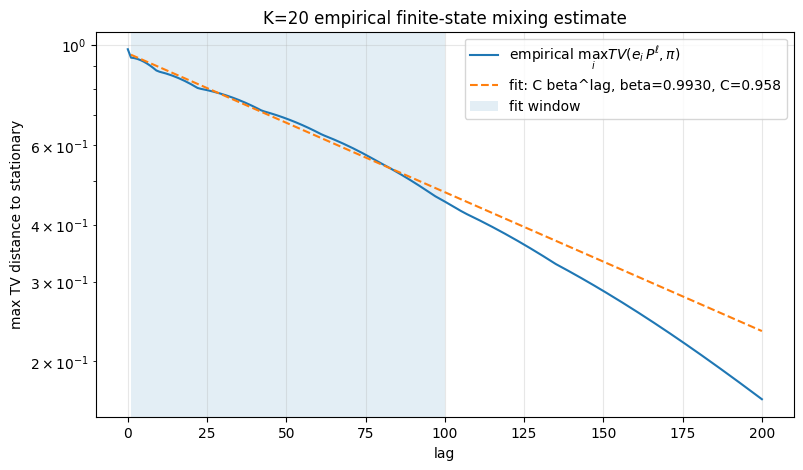


Recommended practical beta_hat for K=20:
beta_hat = beta_tv_fit = 0.992960
SLEM check: beta_slem = 0.985918
TV fit R^2 = 0.9918

Candidate theoretical-style delays using beta_tv_fit:
c_tau=0.25 -> tau=317
c_tau=0.5  -> tau=634
c_tau=1.0  -> tau=1267


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ============================================================
# K=20 finite-state proxy for action-set process A_t = X_t
# ============================================================

K = 20
PCA_DIM = 10
RANDOM_STATE = 0
MAX_TV_LAG = 200
SMOOTHING = 0.0          # use raw empirical transition matrix
FIT_MIN_LAG = 1
FIT_MAX_LAG = 100        # fit early-to-medium decay, not noisy long tail


def flatten_action_sets(instance, drop_intercept=True):
    rows = []

    for X in instance.X_by_t:
        X = np.asarray(X, dtype=float)

        if drop_intercept and X.shape[1] > 1 and np.allclose(X[:, 0], 1.0):
            X = X[:, 1:]

        rows.append(X.reshape(-1))

    return np.vstack(rows)


def estimate_transition_matrix(labels, K, smoothing=0.0):
    counts = np.full((K, K), smoothing, dtype=float)

    for s, sp in zip(labels[:-1], labels[1:]):
        counts[s, sp] += 1.0

    row_sums = counts.sum(axis=1, keepdims=True)

    P = np.divide(
        counts,
        row_sums,
        out=np.ones_like(counts) / K,
        where=row_sums > 0,
    )

    return P, counts


def stationary_distribution(P):
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1.0))
    pi = np.real(vecs[:, idx])

    # Orient and clean numerical noise.
    if pi.sum() < 0:
        pi = -pi

    pi = np.maximum(pi, 0.0)

    if pi.sum() <= 1e-12:
        # Fallback least-squares solve.
        K = P.shape[0]
        A = np.vstack([P.T - np.eye(K), np.ones(K)])
        b = np.concatenate([np.zeros(K), [1.0]])
        pi = np.linalg.lstsq(A, b, rcond=None)[0]
        pi = np.maximum(pi, 0.0)

    pi = pi / pi.sum()
    return pi


def tv(p, q):
    return 0.5 * np.sum(np.abs(p - q))


def tv_mixing_curve(P, max_lag=200):
    K = P.shape[0]
    pi = stationary_distribution(P)

    Ppow = np.eye(K)
    tvs = []

    for lag in range(max_lag + 1):
        max_tv = max(tv(Ppow[i], pi) for i in range(K))
        tvs.append(max_tv)
        Ppow = Ppow @ P

    return np.asarray(tvs), pi


def slem(P):
    vals = np.linalg.eigvals(P)
    mods = np.sort(np.abs(vals))[::-1]
    return float(mods[1])


def fit_beta_from_tv(tvs, min_lag=1, max_lag=100, min_tv=1e-8):
    lags = np.arange(len(tvs))

    mask = (
        (lags >= min_lag)
        & (lags <= max_lag)
        & np.isfinite(tvs)
        & (tvs > min_tv)
        & (tvs < 0.999999)
    )

    x = lags[mask]
    y = np.log(tvs[mask])

    slope, intercept = np.polyfit(x, y, 1)

    beta_hat = float(np.exp(slope))
    Cmix_hat = float(np.exp(intercept))

    yhat = slope * x + intercept
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    return beta_hat, Cmix_hat, r2, x, y, yhat


def graph_reachable(adj, start):
    K = adj.shape[0]
    seen = np.zeros(K, dtype=bool)
    stack = [start]
    seen[start] = True

    while stack:
        u = stack.pop()
        for v in np.where(adj[u])[0]:
            if not seen[v]:
                seen[v] = True
                stack.append(v)

    return seen


def is_irreducible(P, tol=1e-12):
    adj = P > tol
    return all(graph_reachable(adj, s).all() for s in range(P.shape[0]))


def has_self_loop(P, tol=1e-12):
    return bool(np.any(np.diag(P) > tol))


# ============================================================
# Build K=20 states
# ============================================================

F = flatten_action_sets(instance, drop_intercept=True)

F_std = StandardScaler().fit_transform(F)
Z = PCA(n_components=PCA_DIM, random_state=RANDOM_STATE).fit_transform(F_std)

kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(Z)

P, counts = estimate_transition_matrix(labels, K, smoothing=SMOOTHING)

tvs, pi = tv_mixing_curve(P, max_lag=MAX_TV_LAG)

beta_slem = slem(P)
beta_tv_fit, Cmix_tv_fit, tv_fit_r2, x_fit, y_fit, yhat_fit = fit_beta_from_tv(
    tvs,
    min_lag=FIT_MIN_LAG,
    max_lag=FIT_MAX_LAG,
)

# Empirical C for the chosen beta_tv_fit over plotted lags.
# This checks how well C beta^lag upper-envelopes the observed TV curve.
lags = np.arange(len(tvs))
Cmix_emp_envelope = np.max(tvs[1:] / np.maximum(beta_tv_fit ** lags[1:], 1e-300))

T = len(instance.X_by_t)
tau_c025 = int(np.ceil(0.25 * np.log(T) / max(1.0 - beta_tv_fit, 1e-12)))
tau_c05  = int(np.ceil(0.50 * np.log(T) / max(1.0 - beta_tv_fit, 1e-12)))
tau_c1   = int(np.ceil(1.00 * np.log(T) / max(1.0 - beta_tv_fit, 1e-12)))

summary = pd.DataFrame([{
    "K": K,
    "T": T,
    "irreducible_raw": is_irreducible(P),
    "has_self_loop_raw": has_self_loop(P),
    "min_cluster_size": int(np.bincount(labels, minlength=K).min()),
    "median_cluster_size": float(np.median(np.bincount(labels, minlength=K))),
    "max_cluster_size": int(np.bincount(labels, minlength=K).max()),
    "beta_slem": beta_slem,
    "beta_tv_fit": beta_tv_fit,
    "Cmix_tv_fit": Cmix_tv_fit,
    "Cmix_emp_envelope_for_beta_tv": Cmix_emp_envelope,
    "tv_fit_r2": tv_fit_r2,
    "tau_c0.25_from_beta_tv": tau_c025,
    "tau_c0.5_from_beta_tv": tau_c05,
    "tau_c1.0_from_beta_tv": tau_c1,
}])

display(summary.round(6))


# ============================================================
# Plot TV curve and fitted beta
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(lags, tvs, label=r"empirical $\max_i TV(e_i P^\ell,\pi)$")

fit_lags = np.arange(1, MAX_TV_LAG + 1)
plt.plot(
    fit_lags,
    Cmix_tv_fit * (beta_tv_fit ** fit_lags),
    linestyle="--",
    label=fr"fit: C beta^lag, beta={beta_tv_fit:.4f}, C={Cmix_tv_fit:.3f}",
)

plt.axvspan(FIT_MIN_LAG, FIT_MAX_LAG, alpha=0.12, label="fit window")

plt.yscale("log")
plt.xlabel("lag")
plt.ylabel(r"max TV distance to stationary")
plt.title("K=20 empirical finite-state mixing estimate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Recommended beta for practical delay selection
# ============================================================

beta_hat = beta_tv_fit

print("\nRecommended practical beta_hat for K=20:")
print(f"beta_hat = beta_tv_fit = {beta_hat:.6f}")
print(f"SLEM check: beta_slem = {beta_slem:.6f}")
print(f"TV fit R^2 = {tv_fit_r2:.4f}")
print()
print("Candidate theoretical-style delays using beta_tv_fit:")
for c_tau in [0.25, 0.5, 1.0]:
    tau = int(np.ceil(c_tau * np.log(T) / max(1.0 - beta_hat, 1e-12)))
    print(f"c_tau={c_tau:<4} -> tau={tau}")

=== Loading data ===
DATA_DIR: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050
SENSOR_LOC_FILE: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\nodes_gps.csv
VEHICLE_GPS_FILE: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\ATV2-20250812-105042.csv
KEEP_NODES: [1, 2, 3, 4, 5, 7, 8, 9, 10]
DROP_NODES: [6]
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_1_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_2_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_3_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Project

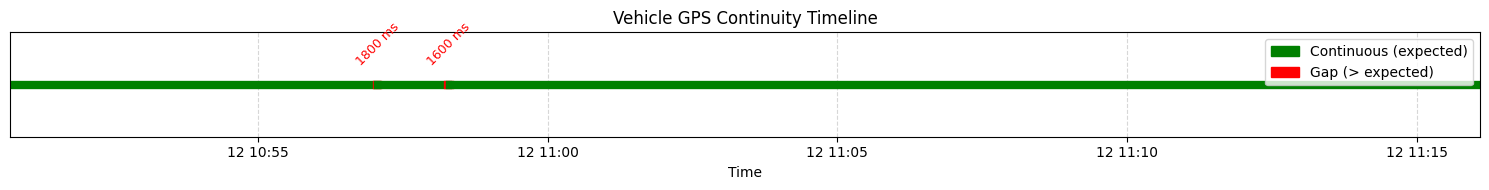


📦 Final Cleaned DataFrames Summary
Using nodes: [1, 2, 3, 4, 5, 7, 8, 9, 10]
Dropped nodes: [6]
Local projected CRS: EPSG:32618
gdf_cleaned: 7598 rows, columns: ['rpi1', 'rpi2', 'rpi3', 'rpi4', 'rpi5', 'rpi7', 'rpi8', 'rpi9', 'rpi10', 'geometry', 'distance_to_1', 'distance_to_2', 'distance_to_3', 'distance_to_4', 'distance_to_5', 'distance_to_7', 'distance_to_8', 'distance_to_9', 'distance_to_10']
normalized_cleaned: 7598 rows, columns: ['rpi1', 'rpi2', 'rpi3', 'rpi4', 'rpi5', 'rpi7', 'rpi8', 'rpi9', 'rpi10', 'Latitude', 'Longitude', 'distance_to_1', 'distance_to_2', 'distance_to_3', 'distance_to_4', 'distance_to_5', 'distance_to_7', 'distance_to_8', 'distance_to_9', 'distance_to_10']

✅ Valid time indices: 7473 out of 7598 total
First 10 valid indices: [61, 62, 63, 64, 65, 66, 67, 68, 69, 70]

=== Sanity checks ===
gdf_cleaned shape: (7598, 19)
normalized_cleaned shape: (7598, 20)
gdf_nodes shape: (9, 5)
num valid_indices: 7473
first 10 valid_indices: [61, 62, 63, 64, 65, 66, 67, 68,

,node,rows,rss_mean_db,rss_std_db,dist_mean_m,corr_rssi_logdist
0,1,7598,51.346497,6.720826,31.834233,-0.717834
1,2,7598,52.725864,7.429672,27.807666,-0.859250
2,3,7598,49.861221,7.231398,28.482468,-0.782619
3,4,7598,50.435837,4.936367,35.473038,-0.644415
4,5,7598,53.194828,5.833317,32.686417,-0.840937
5,7,7598,52.487495,4.522201,30.936937,-0.843171
6,8,7598,49.472500,5.557532,31.202846,-0.854367
7,9,7598,45.244522,8.430805,40.979794,-0.832723
8,10,7598,48.512157,6.380071,43.655583,-0.739060



=== Head of cleaned data ===


,rpi1,rpi2,rpi3,rpi4,rpi5,rpi7,rpi8,rpi9,rpi10,geometry,distance_to_1,distance_to_2,distance_to_3,distance_to_4,distance_to_5,distance_to_7,distance_to_8,distance_to_9,distance_to_10
datetime,,,,,,,,,,,,,,,,,,,
2025-08-12 10:50:43.200,43.445400,44.123062,41.126652,49.630707,46.481709,48.688774,47.938938,43.521324,40.603233,POINT (384143.669 4356622.344),59.650629,47.940491,37.437128,20.786139,42.780280,52.730310,60.708636,74.893078,81.771073
2025-08-12 10:50:43.400,42.865402,39.572495,42.362968,47.287933,47.614372,49.732292,43.902771,45.601620,38.006409,POINT (384143.67 4356622.345),59.651812,47.941716,37.438353,20.787375,42.781248,52.731537,60.709871,74.894302,81.772306
2025-08-12 10:50:43.600,43.462921,44.139351,41.358772,47.468357,47.478386,49.537773,43.273121,44.078995,37.388950,POINT (384143.67 4356622.345),59.651554,47.941498,37.438134,20.787186,42.780925,52.731398,60.709673,74.894168,81.772102
2025-08-12 10:50:43.800,43.814564,44.314713,40.645618,47.835808,47.618999,49.495544,44.241482,33.783623,36.781944,POINT (384143.67 4356622.345),59.651890,47.941818,37.438454,20.787491,42.781265,52.731672,60.709982,74.894439,81.772415
2025-08-12 10:50:44.000,43.052006,41.765579,41.098129,46.930164,47.106705,49.171288,49.058743,32.500286,42.921867,POINT (384143.67 4356622.345),59.651731,47.941690,37.438326,20.787383,42.781053,52.731602,60.709869,74.894372,81.772297


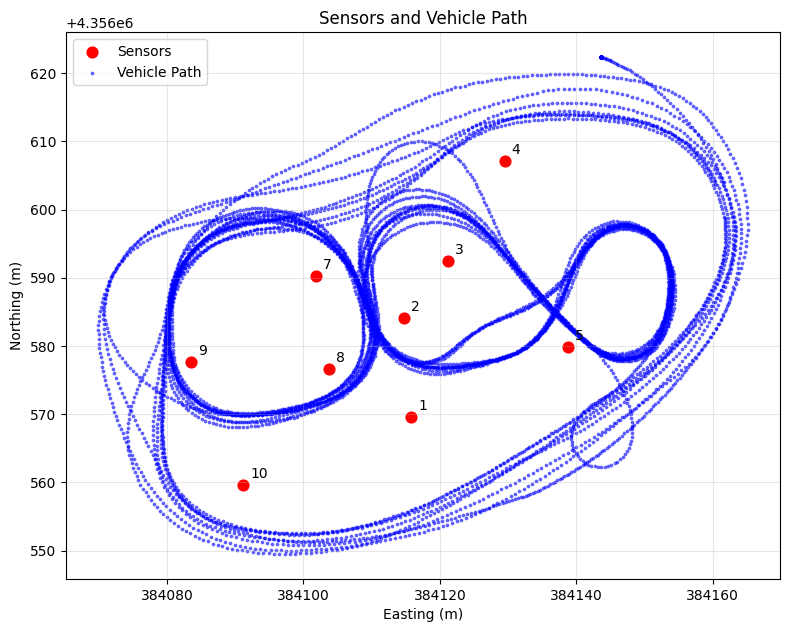

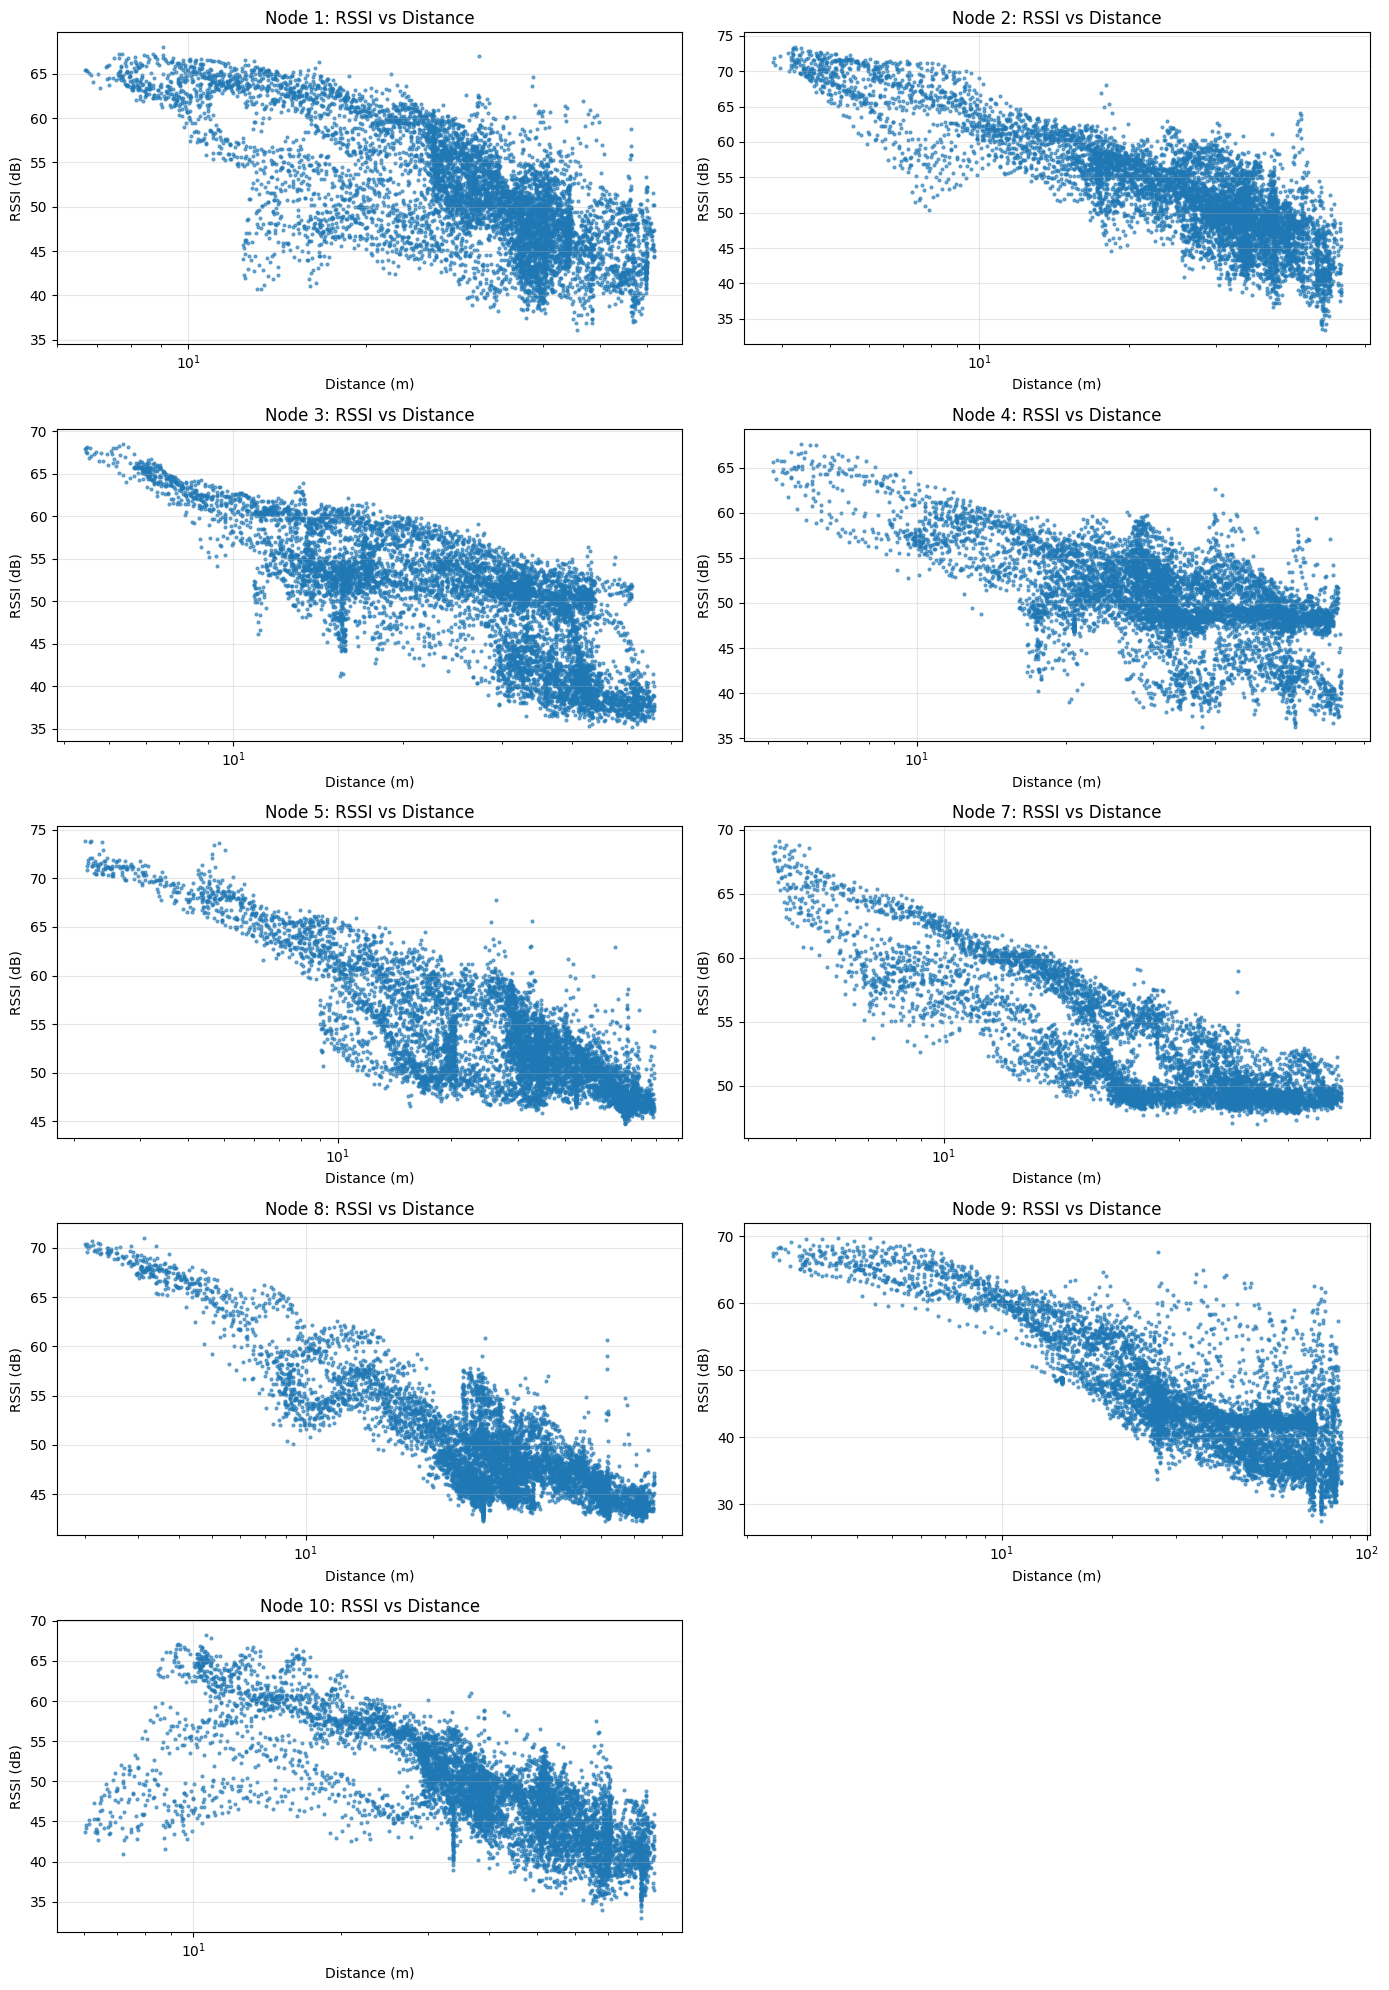


=== Saved outputs ===
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\gdf_cleaned.parquet
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\normalized_cleaned.parquet
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\valid_indices.csv

✅ Extraction and processing completed successfully.


In [9]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Paths / import setup
# =========================
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from dataloader import load_data, plot_sensor_map, plot_rssi_vs_distance

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "20250812_1050"
SENSOR_LOC_FILE = PROJECT_ROOT / "data" / "nodes_gps.csv"

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")])
if not csv_files:
    raise FileNotFoundError(f"No GPS CSV files found in {DATA_DIR}")

VEHICLE_GPS_FILE = DATA_DIR / csv_files[0]

FLAC_NODES = [1,2,3,4,5,6,7,8,9,10]
DROP_NODES = [6]

CHUNK_MS = 10
SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"

print("=== Loading data ===")
print("DATA_DIR:", DATA_DIR)
print("SENSOR_LOC_FILE:", SENSOR_LOC_FILE)
print("VEHICLE_GPS_FILE:", VEHICLE_GPS_FILE)
print("KEEP_NODES:", [n for n in FLAC_NODES if n not in DROP_NODES])
print("DROP_NODES:", DROP_NODES)

# =========================
# Load / process
# =========================
gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=str(DATA_DIR),
    sensor_csv=str(SENSOR_LOC_FILE),
    gps_csv=str(VEHICLE_GPS_FILE),
    node_list=FLAC_NODES,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    drop_nodes=DROP_NODES,
)

# =========================
# Confirmation / sanity checks
# =========================
kept_nodes = [n for n in FLAC_NODES if n not in DROP_NODES]
rss_cols = [f"rpi{n}" for n in kept_nodes]
dist_cols = [f"distance_to_{n}" for n in kept_nodes]

missing_rss = [c for c in rss_cols if c not in gdf_cleaned.columns]
missing_dist = [c for c in dist_cols if c not in gdf_cleaned.columns]

print("\n=== Sanity checks ===")
print("gdf_cleaned shape:", gdf_cleaned.shape)
print("normalized_cleaned shape:", normalized_cleaned.shape)
print("gdf_nodes shape:", gdf_nodes.shape)
print("num valid_indices:", len(valid_indices))
print("first 10 valid_indices:", valid_indices[:10])
print("missing RSS cols:", missing_rss)
print("missing distance cols:", missing_dist)
print("time range:", gdf_cleaned.index.min(), "->", gdf_cleaned.index.max())
print("duplicate timestamps in gdf_cleaned:", gdf_cleaned.index.duplicated().sum())

summary_rows = []
for n in kept_nodes:
    rss_col = f"rpi{n}"
    dist_col = f"distance_to_{n}"
    if rss_col in gdf_cleaned.columns and dist_col in gdf_cleaned.columns:
        sub = gdf_cleaned[[rss_col, dist_col]].dropna()
        summary_rows.append({
            "node": n,
            "rows": len(sub),
            "rss_mean_db": sub[rss_col].mean(),
            "rss_std_db": sub[rss_col].std(),
            "dist_mean_m": sub[dist_col].mean(),
            "corr_rssi_logdist": sub[rss_col].corr(np.log10(sub[dist_col].clip(lower=1e-6)))
        })

summary_df = pd.DataFrame(summary_rows).sort_values("node")
display(summary_df)

print("\n=== Head of cleaned data ===")
display(gdf_cleaned.head())

# =========================
# Quick visuals
# =========================
plot_sensor_map(
    gdf_nodes=gdf_nodes,
    gdf_cleaned=gdf_cleaned,
    title="Sensors and Vehicle Path"
)

plot_rssi_vs_distance(
    gdf_cleaned=gdf_cleaned,
    node_list=kept_nodes,
    ncols=2,
)

# =========================
# Optional save for downstream
# =========================
OUT_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

gdf_cleaned.drop(columns="geometry").to_parquet(OUT_DIR / "gdf_cleaned.parquet")
normalized_cleaned.to_parquet(OUT_DIR / "normalized_cleaned.parquet")
pd.Series(valid_indices, name="valid_index").to_csv(OUT_DIR / "valid_indices.csv", index=False)

print("\n=== Saved outputs ===")
print(OUT_DIR / "gdf_cleaned.parquet")
print(OUT_DIR / "normalized_cleaned.parquet")
print(OUT_DIR / "valid_indices.csv")

print("\n✅ Extraction and processing completed successfully.")

In [16]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# Choose least trimming that achieves location discontinuity < 2m
LOC_THRESHOLD_M = 1.0
MIN_LEN = 6500

feasible = trim_df[
    (trim_df["cycle_len"] >= MIN_LEN)
    & (trim_df["loc_boundary_m"] < LOC_THRESHOLD_M)
].copy()

if len(feasible) == 0:
    print(f"No cycle found with loc_boundary_m < {LOC_THRESHOLD_M}m and cycle_len >= {MIN_LEN}.")
    print("Best available by location:")
    chosen = (
        trim_df[trim_df["cycle_len"] >= MIN_LEN]
        .sort_values(["loc_boundary_m", "total_trim"])
        .iloc[0]
    )
else:
    chosen = feasible.sort_values(["total_trim", "loc_boundary_m"]).iloc[0]

cycle_start_idx = int(chosen["start_idx"])
cycle_end_idx = int(chosen["end_idx"])
cycle_len = int(chosen["cycle_len"])
cycle_indices = np.arange(cycle_start_idx, cycle_end_idx + 1)

trim_config = {
    "cycle_start_idx": cycle_start_idx,
    "cycle_end_idx": cycle_end_idx,
    "cycle_len": cycle_len,
    "start_trim": int(chosen["start_trim"]),
    "end_trim": int(chosen["end_trim"]),
    "total_trim": int(chosen["total_trim"]),
    "loc_boundary_m": float(chosen["loc_boundary_m"]),
    "loc_threshold_m": LOC_THRESHOLD_M,
    "min_len_constraint": MIN_LEN,
    "X_boundary_over_p99_step": float(chosen.get("X_boundary_over_p99_step", np.nan)),
    "reward_boundary_over_p99_step": float(chosen.get("reward_boundary_over_p99_step", np.nan)),
}

# Save inside repo results folder if REPO_ROOT exists; otherwise save relative to current notebook dir.
try:
    save_dir = Path(REPO_ROOT) / "results"
except NameError:
    save_dir = Path("results")

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "cyclic_replay_trim_points.json"

with open(save_path, "w") as f:
    json.dump(trim_config, f, indent=2)

print("Selected cyclic replay trim:")
for k, v in trim_config.items():
    print(f"{k}: {v}")

print(f"\nSaved to: {save_path}")

# Convenience for future cells:
# replay_indices[t] maps replay time t to original instance index.
T_replay = 50_000
replay_indices = cycle_indices[np.arange(T_replay) % cycle_len]

print(f"\nExample replay_indices created for T_replay={T_replay}.")
print(f"First 10 replay indices: {replay_indices[:10]}")
print(f"Last 10 replay indices:  {replay_indices[-10:]}")

Selected cyclic replay trim:
cycle_start_idx: 265
cycle_end_idx: 7472
cycle_len: 7208
start_trim: 265
end_trim: 0
total_trim: 265
loc_boundary_m: 0.9493070013771703
loc_threshold_m: 1.0
min_len_constraint: 6500
X_boundary_over_p99_step: 2.0670854261895935
reward_boundary_over_p99_step: 3.3047650358054774

Saved to: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\cyclic_replay_trim_points.json

Example replay_indices created for T_replay=50000.
First 10 replay indices: [265 266 267 268 269 270 271 272 273 274]
Last 10 replay indices:  [7007 7008 7009 7010 7011 7012 7013 7014 7015 7016]


In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ============================================================
# Load saved trim points
# ============================================================

try:
    trim_path = Path(REPO_ROOT) / "results" / "cyclic_replay_trim_points.json"
except NameError:
    trim_path = Path("results") / "cyclic_replay_trim_points.json"

with open(trim_path, "r") as f:
    trim_config = json.load(f)

cycle_start_idx = int(trim_config["cycle_start_idx"])
cycle_end_idx = int(trim_config["cycle_end_idx"])
cycle_indices = np.arange(cycle_start_idx, cycle_end_idx + 1)
cycle_len = len(cycle_indices)

print(trim_config)
print(f"cycle_len = {cycle_len}")


# ============================================================
# Helper functions
# ============================================================

def flatten_instance_X(instance, drop_intercept=True):
    rows = []
    for X in instance.X_by_t:
        X = np.asarray(X, dtype=float)
        if drop_intercept and X.shape[1] > 1 and np.allclose(X[:, 0], 1.0):
            X = X[:, 1:]
        rows.append(X.reshape(-1))
    return np.vstack(rows)


def estimate_transition_matrix_from_labels(labels, K, circular=True, smoothing=0.0):
    labels = np.asarray(labels, dtype=int)
    counts = np.full((K, K), smoothing, dtype=float)

    for a, b in zip(labels[:-1], labels[1:]):
        counts[a, b] += 1.0

    if circular and len(labels) > 1:
        counts[labels[-1], labels[0]] += 1.0

    row_sums = counts.sum(axis=1, keepdims=True)
    P = np.divide(
        counts,
        row_sums,
        out=np.ones_like(counts) / K,
        where=row_sums > 0,
    )
    return P, counts


def stationary_distribution(P):
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1.0))
    pi = np.real(vecs[:, idx])
    if pi.sum() < 0:
        pi = -pi
    pi = np.maximum(pi, 0.0)

    if pi.sum() <= 1e-12:
        K = P.shape[0]
        A = np.vstack([P.T - np.eye(K), np.ones(K)])
        b = np.concatenate([np.zeros(K), [1.0]])
        pi = np.linalg.lstsq(A, b, rcond=None)[0]
        pi = np.maximum(pi, 0.0)

    return pi / pi.sum()


def tv(p, q):
    return 0.5 * np.sum(np.abs(p - q))


def slem(P):
    vals = np.linalg.eigvals(P)
    mods = np.sort(np.abs(vals))[::-1]
    return float(mods[1]) if len(mods) > 1 else 0.0


def tv_mixing_curve(P, max_lag=100):
    K = P.shape[0]
    pi = stationary_distribution(P)
    Ppow = np.eye(K)
    tvs = []

    for lag in range(max_lag + 1):
        tvs.append(max(tv(Ppow[i], pi) for i in range(K)))
        Ppow = Ppow @ P

    return np.asarray(tvs), pi


def fit_beta_from_tv(tvs, min_lag=1, max_lag=60, min_tv=1e-8):
    lags = np.arange(len(tvs))
    mask = (
        (lags >= min_lag)
        & (lags <= max_lag)
        & np.isfinite(tvs)
        & (tvs > min_tv)
        & (tvs < 0.999999)
    )

    if mask.sum() < 5:
        return np.nan, np.nan, np.nan

    x = lags[mask]
    y = np.log(tvs[mask])

    slope, intercept = np.polyfit(x, y, 1)
    beta_hat = float(np.exp(slope))
    C_hat = float(np.exp(intercept))

    yhat = slope * x + intercept
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    return beta_hat, C_hat, r2


def graph_reachable(adj, start):
    K = adj.shape[0]
    seen = np.zeros(K, dtype=bool)
    stack = [start]
    seen[start] = True

    while stack:
        u = stack.pop()
        for v in np.where(adj[u])[0]:
            if not seen[v]:
                seen[v] = True
                stack.append(v)

    return seen


def is_irreducible(P, tol=1e-12):
    adj = P > tol
    return all(graph_reachable(adj, s).all() for s in range(P.shape[0]))


def has_self_loop(P, tol=1e-12):
    return bool(np.any(np.diag(P) > tol))


# ============================================================
# Define K=20 states once on the trimmed full cycle
# ============================================================

K = 20
PCA_DIM = 10
RANDOM_STATE = 0

F_all = flatten_instance_X(instance, drop_intercept=True)
F_cycle = F_all[cycle_indices]

F_std = StandardScaler().fit_transform(F_cycle)
Z_cycle = PCA(n_components=PCA_DIM, random_state=RANDOM_STATE).fit_transform(F_std)

kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
labels_cycle = kmeans.fit_predict(Z_cycle)

print(f"K={K}, visited states in full cycle = {len(np.unique(labels_cycle))}")
print("Cluster sizes:", np.bincount(labels_cycle, minlength=K))


# ============================================================
# Scan downsampling factors
# ============================================================

def scan_downsample_beta(
    labels_cycle,
    K=20,
    max_stride=150,
    target_beta=0.8,
    max_tv_lag=100,
    smoothing=0.0,
):
    rows = []
    N = len(labels_cycle)

    for stride in range(1, max_stride + 1):
        # Circular downsampling: 0, m, 2m, ...
        # Use one full traversal length approximately N / gcd(N, stride).
        period_len = N // np.gcd(N, stride)
        pos = (np.arange(period_len) * stride) % N
        labels_ds = labels_cycle[pos]

        P, counts = estimate_transition_matrix_from_labels(
            labels_ds,
            K=K,
            circular=True,
            smoothing=smoothing,
        )

        tvs, pi = tv_mixing_curve(P, max_lag=max_tv_lag)
        beta_tv_fit, C_tv_fit, tv_fit_r2 = fit_beta_from_tv(
            tvs,
            min_lag=1,
            max_lag=min(60, max_tv_lag),
        )

        beta_slem = slem(P)
        sizes = np.bincount(labels_ds, minlength=K)

        rows.append({
            "stride": stride,
            "effective_T_per_cycle": len(labels_ds),
            "gcd_cycle_stride": int(np.gcd(N, stride)),
            "visited_states": int(len(np.unique(labels_ds))),
            "min_state_count": int(sizes.min()),
            "median_state_count": float(np.median(sizes)),
            "max_state_count": int(sizes.max()),
            "irreducible": is_irreducible(P),
            "has_self_loop": has_self_loop(P),
            "beta_slem": beta_slem,
            "beta_tv_fit": beta_tv_fit,
            "C_tv_fit": C_tv_fit,
            "tv_fit_r2": tv_fit_r2,
            "target_hit_tv": bool(np.isfinite(beta_tv_fit) and beta_tv_fit < target_beta),
            "target_hit_slem": bool(np.isfinite(beta_slem) and beta_slem < target_beta),
        })

    return pd.DataFrame(rows)


beta_scan_df = scan_downsample_beta(
    labels_cycle,
    K=K,
    max_stride=150,
    target_beta=0.8,
    max_tv_lag=100,
    smoothing=0.0,
)

display(beta_scan_df.round(4))


# ============================================================
# Pick recommended stride
# ============================================================

# Prefer beta_tv_fit < 0.8, all states visited, irreducible, and not too tiny per-cycle sample.
candidates = beta_scan_df[
    (beta_scan_df["beta_tv_fit"] < 0.8)
    & (beta_scan_df["visited_states"] == K)
    & (beta_scan_df["irreducible"])
    & (beta_scan_df["effective_T_per_cycle"] >= 100)
].copy()

if len(candidates) == 0:
    print("No clean stride found with beta_tv_fit < 0.8 under these constraints.")
    print("Best beta_tv_fit rows:")
    display(
        beta_scan_df
        .sort_values(["beta_tv_fit", "stride"])
        .head(15)
        .round(4)
    )
    chosen_stride = int(beta_scan_df.sort_values(["beta_tv_fit", "stride"]).iloc[0]["stride"])
else:
    chosen = candidates.sort_values(["stride"]).iloc[0]
    chosen_stride = int(chosen["stride"])

    print("\nRecommended smallest stride achieving beta_tv_fit < 0.8:")
    display(chosen.to_frame().T.round(4))

print(f"\nchosen_stride = {chosen_stride}")


# ============================================================
# Compact plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(beta_scan_df["stride"], beta_scan_df["beta_tv_fit"], marker="o", markersize=3, label="beta_tv_fit")
ax.plot(beta_scan_df["stride"], beta_scan_df["beta_slem"], marker="s", markersize=3, label="beta_slem")
ax.axhline(0.8, linestyle="--", linewidth=1, label="target beta=0.8")
ax.axvline(chosen_stride, linestyle=":", linewidth=1.5, label=f"chosen stride={chosen_stride}")
ax.set_ylabel("estimated beta")
ax.set_title("Mixing estimate after circular downsampling")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(beta_scan_df["stride"], beta_scan_df["effective_T_per_cycle"], marker="o", markersize=3, label="effective T per cycle")
ax.plot(beta_scan_df["stride"], beta_scan_df["min_state_count"], marker="s", markersize=3, label="min state count")
ax.axvline(chosen_stride, linestyle=":", linewidth=1.5)
ax.set_xlabel("downsampling stride")
ax.set_ylabel("count")
ax.set_title("Data remaining per downsampled cycle")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


# ============================================================
# Save downsampling choice
# ============================================================

downsample_config = {
    **trim_config,
    "K_states": K,
    "pca_dim": PCA_DIM,
    "chosen_downsample_stride": chosen_stride,
    "target_beta": 0.8,
}

try:
    save_dir = Path(REPO_ROOT) / "results"
except NameError:
    save_dir = Path("results")

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "cyclic_replay_downsample_config.json"

with open(save_path, "w") as f:
    json.dump(downsample_config, f, indent=2)

print(f"Saved downsample config to: {save_path}")


# Convenience replay indices with downsampling
T_replay = 50_000
base_positions = (np.arange(cycle_len) * chosen_stride) % cycle_len

# Use the unique periodic orbit induced by chosen_stride.
period_len = cycle_len // np.gcd(cycle_len, chosen_stride)
base_positions = (np.arange(period_len) * chosen_stride) % cycle_len
base_downsampled_cycle_indices = cycle_indices[base_positions]

replay_indices_downsampled = base_downsampled_cycle_indices[
    np.arange(T_replay) % len(base_downsampled_cycle_indices)
]

print(f"Downsampled cycle length = {len(base_downsampled_cycle_indices)}")
print(f"First 10 replay indices: {replay_indices_downsampled[:10]}")
print(f"Last 10 replay indices:  {replay_indices_downsampled[-10:]}")